# Aegis H2O — Machine Learning System

## Project Objective

Aegis H2O uses live water-quality sensor data to determine:

1. Water Health
2. Filter Status

### Live Sensor Inputs

- pH
- TDS
- Flow
- Turbidity
- Photodiode

### ML Pipeline

Live Sensor Data
↓
Data Validation
↓
Data Preprocessing
↓
Feature Engineering
↓
Water Health Model
↓
Filter Status Model
↓
Aegis H2O Decision

In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("imported all libraries successfully")

imported all libraries successfully


In [70]:
data = "data.csv"
df = pd.read_csv(data)
print("data read successfully")

data read successfully


In [71]:
print("rows: ", df.shape[0])
print("columns: ", df.shape[1])
df.head()

rows:  46268
columns:  21


,sample_id,flow_lpm,tds_mgl,ph,turbidity_ntu,photodiode_mv,conductivity_us,dissolved_o2_mgl,temperature_c,ph_deviation,...,flow_anomaly,do_status,tds_category,filter_eff_pct,filter_life_hr,filter_status,water_health,filter_status_code,water_health_code,source
0,0,61.025,112.691,7.178,0.093,3252.9,204.89,-1.000,-1.000,0.178,...,0,Unknown,Excellent,88.459,4404.193,Normal,Safe,2,2,greywater_sensors
1,1,64.093,485.924,6.054,6.183,977.0,883.50,-1.000,-1.000,0.946,...,0,Unknown,Good,85.386,3917.251,Degraded,Moderate,1,1,greywater_sensors
2,2,500.000,697.812,7.704,5.790,1016.2,1268.75,9.205,21.000,0.704,...,1,Good,Fair,85.620,3960.200,Degraded,Unsafe,1,0,usgs_river_stations
3,3,500.000,521.414,8.028,5.493,1085.5,948.03,5.909,27.562,1.028,...,1,Acceptable,Good,82.120,3795.500,Replace,Moderate,0,1,usgs_river_stations
4,4,500.000,690.757,7.866,5.199,1166.6,1255.92,10.341,16.406,0.866,...,1,Good,Fair,87.430,4017.000,Degraded,Unsafe,1,0,usgs_river_stations


In [72]:
print("columns")

for number, column in enumerate(df.columns, start=1):
    print(f"{number:2}. {column}")

columns
 1. sample_id
 2. flow_lpm
 3. tds_mgl
 4. ph
 5. turbidity_ntu
 6. photodiode_mv
 7. conductivity_us
 8. dissolved_o2_mgl
 9. temperature_c
10. ph_deviation
11. contamination_index
12. flow_anomaly
13. do_status
14. tds_category
15. filter_eff_pct
16. filter_life_hr
17. filter_status
18. water_health
19. filter_status_code
20. water_health_code
21. source


In [73]:
df.dtypes

sample_id                int64
flow_lpm               float64
tds_mgl                float64
ph                     float64
turbidity_ntu          float64
photodiode_mv          float64
conductivity_us        float64
dissolved_o2_mgl       float64
temperature_c          float64
ph_deviation           float64
contamination_index    float64
flow_anomaly             int64
do_status                  str
tds_category               str
filter_eff_pct         float64
filter_life_hr         float64
filter_status              str
water_health               str
filter_status_code       int64
water_health_code        int64
source                     str
dtype: object

In [74]:
missing_values = df.isnull().sum()
print("missing values: ", missing_values)

missing values:  sample_id              0
flow_lpm               0
tds_mgl                0
ph                     0
turbidity_ntu          0
photodiode_mv          0
conductivity_us        0
dissolved_o2_mgl       0
temperature_c          0
ph_deviation           0
contamination_index    0
flow_anomaly           0
do_status              0
tds_category           0
filter_eff_pct         0
filter_life_hr         0
filter_status          0
water_health           0
filter_status_code     0
water_health_code      0
source                 0
dtype: int64


In [75]:
duplicate = df.duplicated().sum()
print("duplicate values: ", duplicate)

duplicate values:  0


In [76]:
print("targets")
print(df['water_health'].value_counts())
print(df['water_health_code'].value_counts())
print(df['filter_status'].value_counts())
print(df['filter_status_code'].value_counts())

targets
water_health
Unsafe      18457
Moderate    16198
Safe        11613
Name: count, dtype: int64
water_health_code
0    18457
1    16198
2    11613
Name: count, dtype: int64
filter_status
Degraded    19799
Replace     13085
Normal      12053
Good         1331
Name: count, dtype: int64
filter_status_code
1    19799
0    13085
2    12053
3     1331
Name: count, dtype: int64


In [77]:
Feature =['pH', 'tds_mgi', 'flow_lpm', 'turbidity_ntu', 'photodiode_mv']

target_health = ['water_health_code']
target_filter = ['filter_status_code']

print('Input')
for f in Feature:
    print(f)

print("----------------------------------------")
   
print('output')
print('water_health : ', target_health)
print('filter_status : ', target_filter)

Input
pH
tds_mgi
flow_lpm
turbidity_ntu
photodiode_mv
----------------------------------------
output
water_health :  ['water_health_code']
filter_status :  ['filter_status_code']


# 5. Aegis H2O Sensor Data Analysis

The Aegis H2O ML system will receive only five measurements from the
physical sensors:

- pH
- TDS
- Flow
- Turbidity
- Photodiode

Before training the model, we need to understand the distribution and
quality of each sensor.

We will check:

1. Minimum and maximum values
2. Mean and median
3. Standard deviation
4. Missing values
5. Potentially invalid values
6. Outliers

We will NOT remove values simply because they look unusual.

A sensor reading may be unusual because it represents genuinely poor
water quality. Therefore, we must distinguish between:

- a legitimate extreme measurement
- a sensor error
- a missing/sentinel value

In [78]:
sensor_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

sensor_summary = df[sensor_features].describe().T

sensor_summary

,count,mean,std,min,25%,50%,75%,max
ph,46268.0,7.579079,0.555238,6.000,7.47300,7.769,7.866,9.0
tds_mgl,46268.0,463.942891,230.261474,0.006,286.98625,493.191,634.309,1776.5
flow_lpm,46268.0,308.954376,223.081727,1.003,59.16000,500.000,500.000,500.0
turbidity_ntu,46268.0,5.920780,8.324595,0.000,4.70600,5.144,5.567,100.0
photodiode_mv,46268.0,1275.927483,555.101676,0.000,1082.50000,1179.700,1290.300,3300.0


In [79]:
print("SENSOR RANGES")
print("=" * 50)

for feature in sensor_features:
    print(f"\n{feature}")
    print(f"  Minimum : {df[feature].min()}")
    print(f"  Maximum : {df[feature].max()}")
    print(f"  Mean    : {df[feature].mean():.3f}")
    print(f"  Median  : {df[feature].median():.3f}")

SENSOR RANGES

ph
  Minimum : 6.0
  Maximum : 9.0
  Mean    : 7.579
  Median  : 7.769

tds_mgl
  Minimum : 0.006
  Maximum : 1776.5
  Mean    : 463.943
  Median  : 493.191

flow_lpm
  Minimum : 1.003
  Maximum : 500.0
  Mean    : 308.954
  Median  : 500.000

turbidity_ntu
  Minimum : 0.0
  Maximum : 100.0
  Mean    : 5.921
  Median  : 5.144

photodiode_mv
  Minimum : 0.0
  Maximum : 3300.0
  Mean    : 1275.927
  Median  : 1179.700


## Sensor Distributions

Numerical summaries tell us the boundaries of the data, but graphs allow
us to see the shape of the distributions.

We will use histograms to determine whether the sensor values are:

- normally distributed
- skewed
- clustered
- containing unusual values
- affected by extreme outliers

This is important before deciding how to preprocess the data.

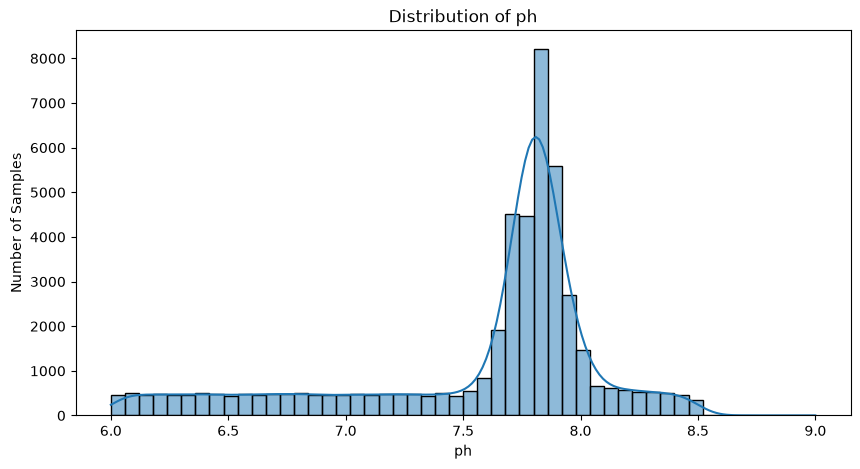

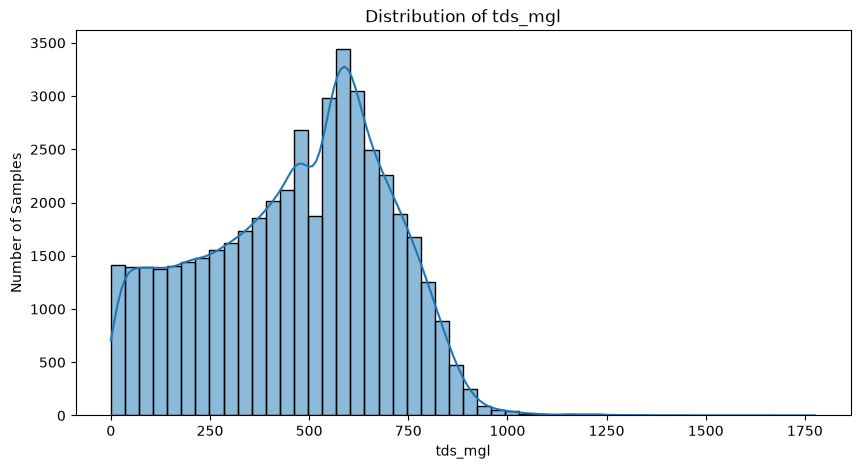

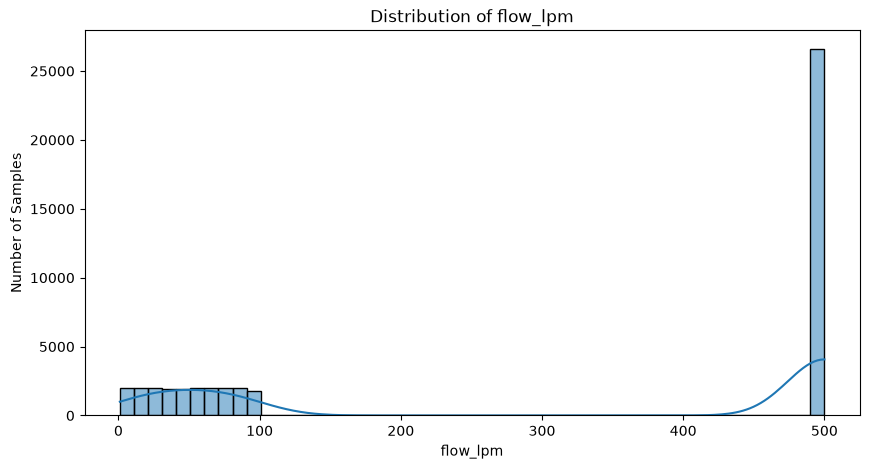

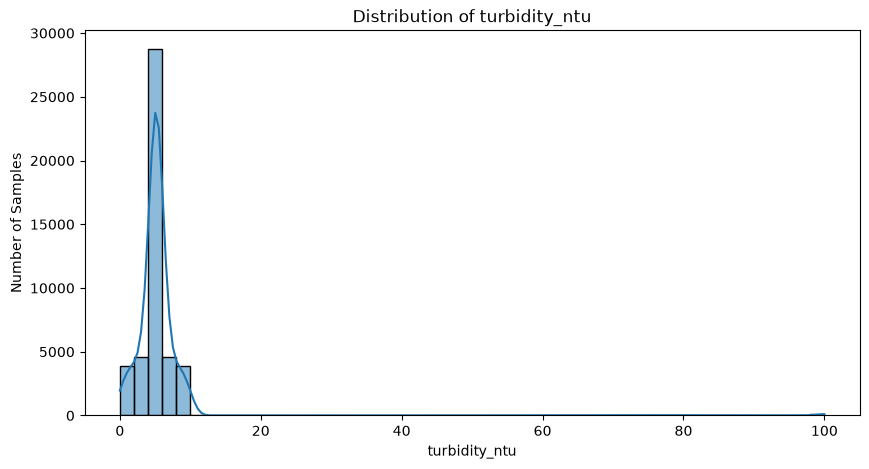

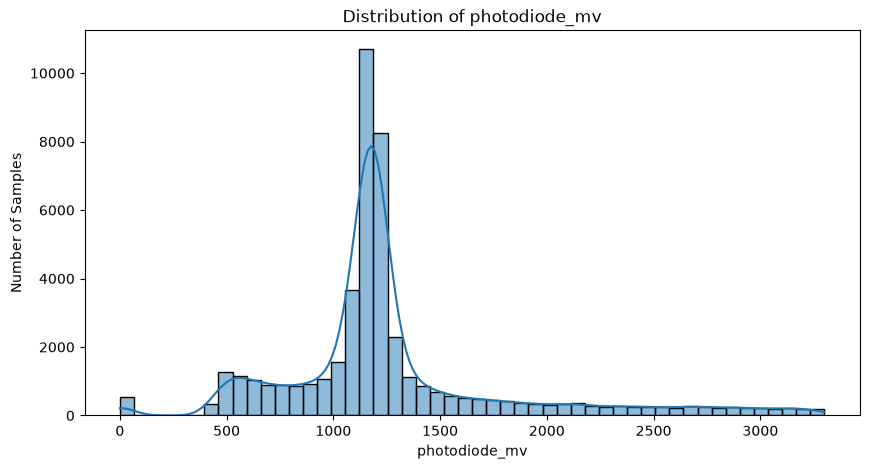

In [80]:
for feature in sensor_features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df[feature],
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Samples")

    plt.show()

## 5.1 Sensor Boundary Analysis

Before removing extreme values, we need to determine whether they are:

- genuine measurements
- sensor operating limits
- saturated readings
- data-entry errors

A value at the exact minimum or maximum is especially important because
many sensors have physical or electronic measurement limits.

We will count how frequently each sensor reaches its boundaries.

In [81]:
print("BOUNDARY VALUE COUNTS")
print("=" * 60)

for feature in sensor_features:
    
    minimum = df[feature].min()
    maximum = df[feature].max()
    
    min_count = (df[feature] == minimum).sum()
    max_count = (df[feature] == maximum).sum()
    
    print(f"\n{feature}")
    print(f"  Minimum value : {minimum}")
    print(f"  Minimum count : {min_count}")
    print(f"  Maximum value : {maximum}")
    print(f"  Maximum count : {max_count}")

BOUNDARY VALUE COUNTS

ph
  Minimum value : 6.0
  Minimum count : 5
  Maximum value : 9.0
  Maximum count : 1

tds_mgl
  Minimum value : 0.006
  Minimum count : 1
  Maximum value : 1776.5
  Maximum count : 1

flow_lpm
  Minimum value : 1.003
  Minimum count : 1
  Maximum value : 500.0
  Maximum count : 26612

turbidity_ntu
  Minimum value : 0.0
  Minimum count : 2
  Maximum value : 100.0
  Maximum count : 119

photodiode_mv
  Minimum value : 0.0
  Minimum count : 249
  Maximum value : 3300.0
  Maximum count : 19


In [82]:
percentiles = [0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]

sensor_percentiles = df[sensor_features].quantile(percentiles).T

sensor_percentiles

,0.00,0.01,0.05,0.25,0.50,0.75,0.95,0.99,1.00
ph,6.000,6.05867,6.29200,7.47300,7.769,7.866,8.225,8.44433,9.0
tds_mgl,0.006,11.72538,58.04755,286.98625,493.191,634.309,803.651,888.32200,1776.5
flow_lpm,1.003,3.23934,12.53035,59.16000,500.000,500.000,500.000,500.00000,500.0
turbidity_ntu,0.000,0.24100,1.17200,4.70600,5.144,5.567,9.087,58.66400,100.0
photodiode_mv,0.000,17.20000,536.00000,1082.50000,1179.700,1290.300,2609.530,3145.53300,3300.0


In [83]:
for feature in sensor_features:
    
    print(f"\n========== {feature} ==========")
    
    print("Lowest 10 unique values:")
    print(np.sort(df[feature].unique())[:10])
    
    print("\nHighest 10 unique values:")
    print(np.sort(df[feature].unique())[-10:])


========== ph ==========
Lowest 10 unique values:
[6.    6.001 6.002 6.003 6.004 6.005 6.006 6.007 6.008 6.009]

Highest 10 unique values:
[8.514 8.546 8.579 8.611 8.644 8.7   8.773 8.87  8.968 9.   ]

========== tds_mgl ==========
Lowest 10 unique values:
[0.006 0.015 0.026 0.067 0.079 0.114 0.12  0.121 0.126 0.155]

Highest 10 unique values:
[1347.5 1364.  1380.5 1397.  1424.5 1463.  1512.5 1534.5 1622.5 1776.5]

========== flow_lpm ==========
Lowest 10 unique values:
[1.003 1.01  1.013 1.014 1.016 1.018 1.028 1.035 1.043 1.044]

Highest 10 unique values:
[ 99.96   99.963  99.967  99.971  99.976  99.98   99.986  99.998  99.999
 500.   ]

========== turbidity_ntu ==========
Lowest 10 unique values:
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]

Highest 10 unique values:
[ 92.8  93.6  94.4  95.2  96.   96.8  97.6  98.4  99.2 100. ]

========== photodiode_mv ==========
Lowest 10 unique values:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]

Highest 10 unique values:
[3293.1 

# 5.2 Sensor Distribution Analysis

The previous statistics showed that several sensors contain extreme or
boundary values.

We will now visualize each sensor using both:

- Histogram
- Box plot

The histogram shows the overall distribution.

The box plot helps identify extreme observations.

Important:
An outlier is not automatically a bad measurement.

For Aegis H2O, an extreme sensor value may represent genuinely poor water
quality. Therefore, we will investigate extreme values before removing them.

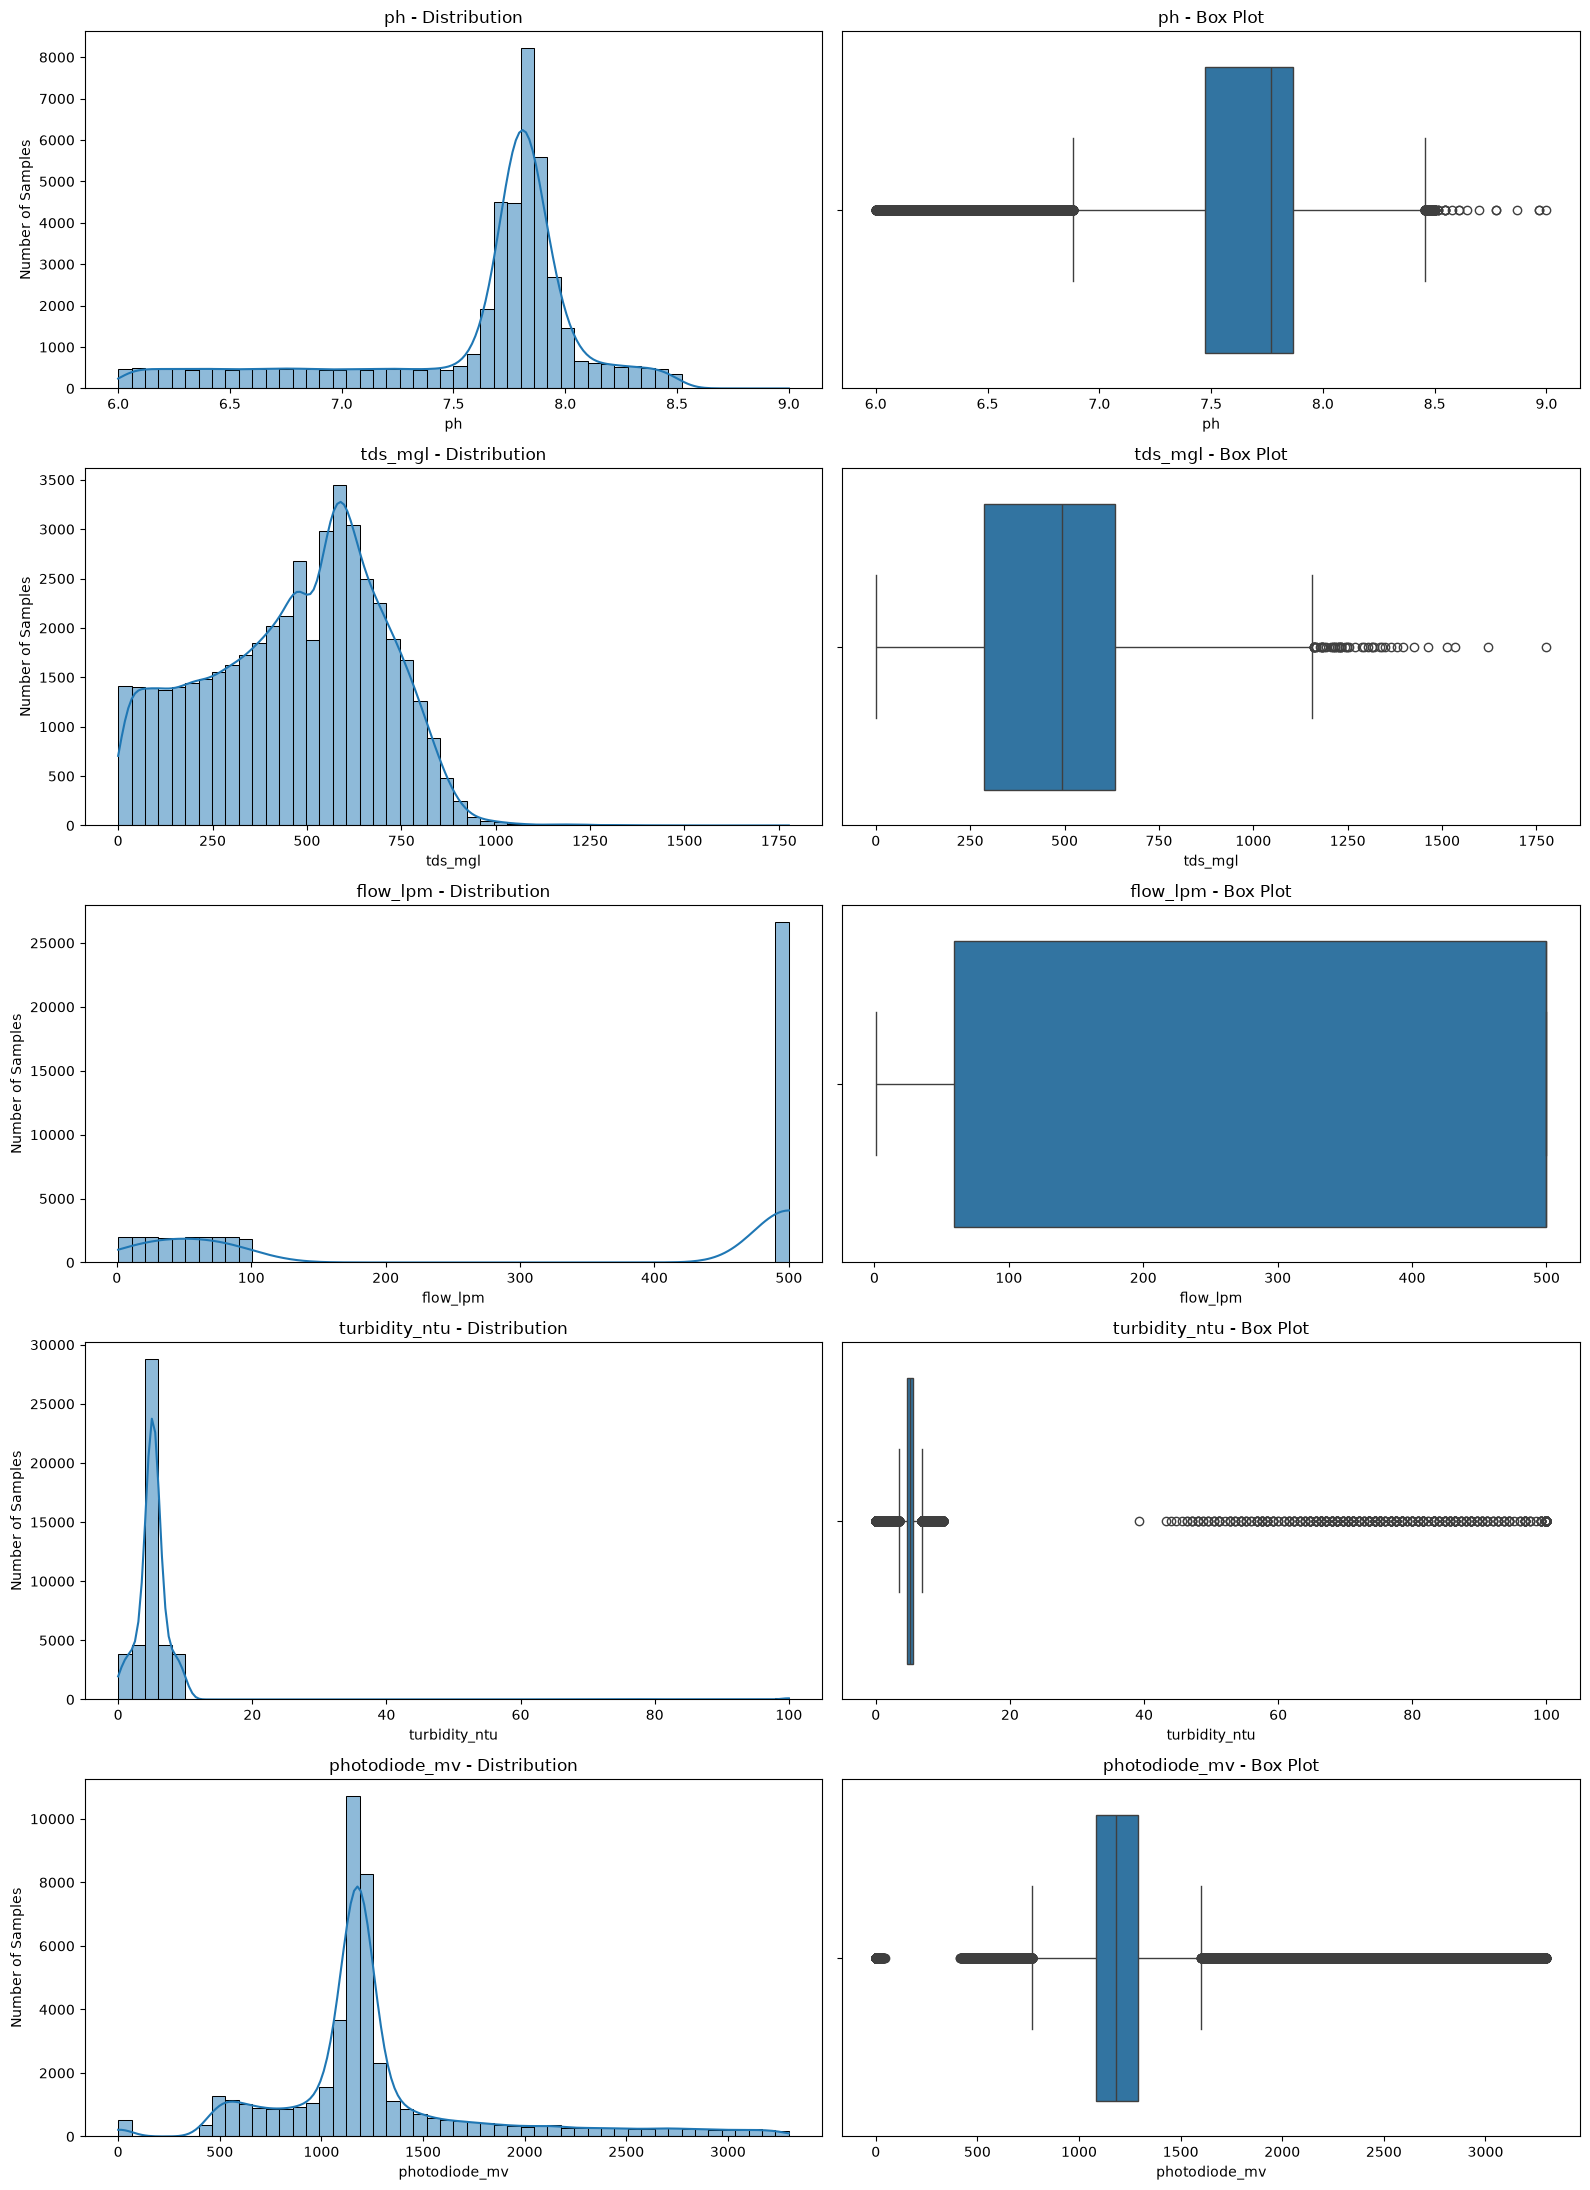

In [84]:
fig, axes = plt.subplots(
    len(sensor_features),
    2,
    figsize=(16, 22)
)

for i, feature in enumerate(sensor_features):

    # Histogram
    sns.histplot(
        df[feature],
        bins=50,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f"{feature} - Distribution")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Number of Samples")

    # Box plot
    sns.boxplot(
        x=df[feature],
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f"{feature} - Box Plot")
    axes[i, 1].set_xlabel(feature)

plt.tight_layout()
plt.show()

# 5.3 Investigating Extreme Sensor Values

We will inspect the observations at the extreme ends of each sensor.

Instead of deleting them based purely on statistical rules, we will compare
them with their associated water-health and filter-status labels.

This helps determine whether an extreme value represents:

- genuine water-quality conditions
- sensor saturation
- data-generation artifacts
- potential measurement errors

In [85]:
for feature in sensor_features:

    print("\n" + "=" * 70)
    print(f"EXTREME VALUES: {feature}")
    print("=" * 70)

    print("\nLowest 10:")
    print(
        df[
            [
                feature,
                "water_health",
                "filter_status"
            ]
        ]
        .sort_values(feature)
        .head(10)
    )

    print("\nHighest 10:")
    print(
        df[
            [
                feature,
                "water_health",
                "filter_status"
            ]
        ]
        .sort_values(feature, ascending=False)
        .head(10)
    )


EXTREME VALUES: ph

Lowest 10:
          ph water_health filter_status
33754  6.000     Moderate      Degraded
19945  6.000       Unsafe      Degraded
1887   6.000     Moderate      Degraded
5374   6.000       Unsafe        Normal
21024  6.000     Moderate      Degraded
29649  6.001       Unsafe      Degraded
12679  6.001     Moderate        Normal
20625  6.001     Moderate        Normal
9934   6.001         Safe        Normal
35554  6.001     Moderate      Degraded

Highest 10:
          ph water_health filter_status
36779  9.000     Moderate       Replace
14820  8.968     Moderate       Replace
26448  8.968       Unsafe       Replace
3058   8.870       Unsafe        Normal
8419   8.773     Moderate       Replace
2851   8.773       Unsafe      Degraded
13356  8.700       Unsafe          Good
6983   8.644     Moderate       Replace
39549  8.611       Unsafe        Normal
20746  8.611     Moderate       Replace

EXTREME VALUES: tds_mgl

Lowest 10:
       tds_mgl water_health filter_sta

In [86]:
flow_counts = (
    df["flow_lpm"]
    .value_counts()
    .sort_index(ascending=False)
)

print(flow_counts.head(20))

flow_lpm
500.000    26612
99.999         1
99.998         1
99.986         1
99.980         1
99.976         1
99.971         1
99.967         1
99.963         1
99.960         2
99.955         2
99.943         1
99.942         1
99.939         1
99.938         1
99.924         2
99.902         1
99.900         1
99.899         1
99.893         1
Name: count, dtype: int64


In [87]:
print("\nFlow value distribution:")
print(df["flow_lpm"].value_counts().head(20))


Flow value distribution:
flow_lpm
500.000    26612
74.860         4
27.973         4
66.807         4
47.775         4
40.218         4
46.746         4
78.479         4
82.085         3
84.260         3
13.169         3
24.223         3
97.233         3
5.928          3
7.236          3
67.282         3
71.001         3
95.352         3
38.802         3
61.007         3
Name: count, dtype: int64


# 5.4 Individual Sensor vs Water Health

Before training a machine learning model, we need to understand how each
sensor relates to the target independently.

This is important because a very strong relationship may indicate that:

1. The sensor is genuinely highly informative, or
2. The target labels were generated using that sensor.

We will investigate both possibilities.

We will NOT use this analysis to remove features.

In [88]:
# Water health distribution for each sensor

for feature in sensor_features:

    print("\n" + "=" * 70)
    print(f"{feature.upper()} vs WATER HEALTH")
    print("=" * 70)

    summary = pd.crosstab(
        pd.qcut(
            df[feature],
            q=10,
            duplicates="drop"
        ),
        df["water_health"],
        normalize="index"
    ) * 100

    print(summary.round(2))


PH vs WATER HEALTH
water_health    Moderate   Safe  Unsafe
ph                                     
(5.999, 6.591]     51.48  29.32   19.20
(6.591, 7.178]     15.33  63.99   20.67
(7.178, 7.639]     24.10  50.64   25.26
(7.639, 7.736]     45.50  10.61   43.89
(7.736, 7.769]     45.80   5.44   48.76
(7.769, 7.819]     44.83   8.69   46.48
(7.819, 7.866]     39.72   6.18   54.11
(7.866, 7.898]     29.71   9.54   60.75
(7.898, 8.028]     31.70  16.32   51.98
(8.028, 9.0]       15.32  54.72   29.96

TDS_MGL vs WATER HEALTH
water_health        Moderate   Safe  Unsafe
tds_mgl                                    
(0.005, 117.515]        8.45  71.34   20.21
(117.515, 232.61]       8.56  71.62   19.82
(232.61, 337.093]      19.47  62.31   18.22
(337.093, 422.632]     62.97  24.13   12.89
(422.632, 493.191]     69.41  18.77   11.81
(493.191, 563.75]      96.73   1.88    1.40
(563.75, 606.086]      81.57   0.00   18.43
(606.086, 669.589]      0.00   0.00  100.00
(669.589, 747.204]      0.00   0.00

In [89]:
for feature in sensor_features:

    print("\n" + "=" * 70)
    print(f"{feature.upper()} vs FILTER STATUS")
    print("=" * 70)

    summary = pd.crosstab(
        pd.qcut(
            df[feature],
            q=10,
            duplicates="drop"
        ),
        df["filter_status"],
        normalize="index"
    ) * 100

    print(summary.round(2))


PH vs FILTER STATUS
filter_status   Degraded   Good  Normal  Replace
ph                                              
(5.999, 6.591]     56.87   1.10   34.39     7.64
(6.591, 7.178]     48.70   3.07   44.10     4.13
(7.178, 7.639]     37.94   5.04   44.15    12.87
(7.639, 7.736]     39.90   1.48   14.30    44.31
(7.736, 7.769]     42.16   0.56   12.56    44.72
(7.769, 7.819]     40.03   1.24   13.16    45.57
(7.819, 7.866]     45.03   0.32   11.82    42.84
(7.866, 7.898]     43.52   1.14   16.33    39.01
(7.898, 8.028]     42.14   3.27   20.82    33.77
(8.028, 9.0]       30.03  12.75   53.73     3.50

TDS_MGL vs FILTER STATUS
filter_status       Degraded   Good  Normal  Replace
tds_mgl                                             
(0.005, 117.515]       27.86  13.31   58.42     0.41
(117.515, 232.61]      35.92   7.18   53.97     2.94
(232.61, 337.093]      40.67   3.63   41.82    13.88
(337.093, 422.632]     38.00   1.14   28.82    32.04
(422.632, 493.191]     32.89   0.77   19.46    

In [90]:
print("========== BOUNDARY LABEL ANALYSIS ==========")

boundary_tests = {
    "flow_500": df["flow_lpm"] == 500,
    "turbidity_100": df["turbidity_ntu"] == 100,
    "photodiode_0": df["photodiode_mv"] == 0,
    "photodiode_3300": df["photodiode_mv"] == 3300,
}

for name, mask in boundary_tests.items():

    subset = df.loc[mask]

    print(f"\n{name}")
    print("Samples:", len(subset))

    print("\nWater Health:")
    print(
        subset["water_health"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nFilter Status:")
    print(
        subset["filter_status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

========== BOUNDARY LABEL ANALYSIS ==========

flow_500
Samples: 26612

Water Health:
water_health
Unsafe      54.76
Moderate    42.90
Safe         2.34
Name: proportion, dtype: float64

Filter Status:
filter_status
Replace     46.72
Degraded    43.19
Normal       9.62
Good         0.47
Name: proportion, dtype: float64

turbidity_100
Samples: 119

Water Health:
water_health
Unsafe    100.0
Name: proportion, dtype: float64

Filter Status:
filter_status
Good        46.22
Normal      43.70
Degraded     9.24
Replace      0.84
Name: proportion, dtype: float64

photodiode_0
Samples: 249

Water Health:
water_health
Unsafe    100.0
Name: proportion, dtype: float64

Filter Status:
filter_status
Normal      55.02
Good        23.29
Degraded    20.48
Replace      1.20
Name: proportion, dtype: float64

photodiode_3300
Samples: 19

Water Health:
water_health
Safe        94.74
Moderate     5.26
Name: proportion, dtype: float64

Filter Status:
filter_status
Normal      73.68
Degraded    15.79
Good    

# 6. Sensor Data Validation

Before modifying the dataset, we will validate the five sensor inputs used
by Aegis H2O.

A valid sensor reading should satisfy basic numerical constraints:

- pH must be within the physical pH scale of 0–14.
- TDS cannot be negative.
- Flow cannot be negative for the Aegis H2O flow direction.
- Turbidity cannot be negative.
- Photodiode voltage cannot be negative.

These checks identify values that are mathematically/physically impossible.

Important:
We will NOT remove statistically unusual values merely because they are
outliers. Extreme values may represent genuine contaminated water.

We will also check for NaN and infinite values.

In [91]:
# ==========================================
# SENSOR DATA VALIDATION
# ==========================================

sensor_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

print("Checking sensor data...")
print("=" * 60)

# Check missing values
print("\nMissing values:")
print(df[sensor_features].isnull().sum())

# Check infinite values
print("\nInfinite values:")
print(np.isinf(df[sensor_features]).sum())

# Check physically invalid values
print("\nPotentially invalid values:")

print("pH < 0:", (df["ph"] < 0).sum())
print("pH > 14:", (df["ph"] > 14).sum())

print("TDS < 0:", (df["tds_mgl"] < 0).sum())

print("Flow < 0:", (df["flow_lpm"] < 0).sum())

print("Turbidity < 0:", (df["turbidity_ntu"] < 0).sum())

print("Photodiode < 0:", (df["photodiode_mv"] < 0).sum())

Checking sensor data...

Missing values:
ph               0
tds_mgl          0
flow_lpm         0
turbidity_ntu    0
photodiode_mv    0
dtype: int64

Infinite values:
ph               0
tds_mgl          0
flow_lpm         0
turbidity_ntu    0
photodiode_mv    0
dtype: int64

Potentially invalid values:
pH < 0: 0
pH > 14: 0
TDS < 0: 0
Flow < 0: 0
Turbidity < 0: 0
Photodiode < 0: 0


# 7. Target Label Validation

Aegis H2O has two prediction targets:

### Water Health
- Safe
- Moderate
- Unsafe

### Filter Status
- Good
- Normal
- Degraded
- Replace

The numerical code columns will eventually be used by the ML algorithms,
but we first verify that the human-readable labels and numerical codes
are consistent.

Incorrect or missing target labels are more serious than unusual sensor
values because the model learns directly from these labels.

In [92]:
# ==========================================
# LABEL ↔ CODE CONSISTENCY
# ==========================================

print("Water Health label/code combinations:")
print(
    pd.crosstab(
        df["water_health"],
        df["water_health_code"]
    )
)

print("\nFilter Status label/code combinations:")
print(
    pd.crosstab(
        df["filter_status"],
        df["filter_status_code"]
    )
)

Water Health label/code combinations:
water_health_code      0      1      2
water_health                          
Moderate               0  16198      0
Safe                   0      0  11613
Unsafe             18457      0      0

Filter Status label/code combinations:
filter_status_code      0      1      2     3
filter_status                                
Degraded                0  19799      0     0
Good                    0      0      0  1331
Normal                  0      0  12053     0
Replace             13085      0      0     0


In [93]:
# ==========================================
# TARGET MISSING VALUES
# ==========================================

target_columns = [
    "water_health",
    "water_health_code",
    "filter_status",
    "filter_status_code"
]

print(df[target_columns].isnull().sum())

water_health          0
water_health_code     0
filter_status         0
filter_status_code    0
dtype: int64


In [94]:
# ==========================================
# DATA QUALITY REPORT
# ==========================================

quality_report = pd.DataFrame({
    "Missing": df[sensor_features].isnull().sum(),
    "Unique Values": df[sensor_features].nunique(),
    "Minimum": df[sensor_features].min(),
    "Maximum": df[sensor_features].max(),
    "Mean": df[sensor_features].mean(),
    "Median": df[sensor_features].median()
})

quality_report

,Missing,Unique Values,Minimum,Maximum,Mean,Median
ph,0,2509,6.000,9.0,7.579079,7.769
tds_mgl,0,19831,0.006,1776.5,463.942891,493.191
flow_lpm,0,17815,1.003,500.0,308.954376,500.000
turbidity_ntu,0,8915,0.000,100.0,5.920780,5.144
photodiode_mv,0,15568,0.000,3300.0,1275.927483,1179.700


In [95]:
# ==========================================
# TARGET LABEL DISTRIBUTION
# ==========================================

print("========== WATER HEALTH ==========")
print(df["water_health"].value_counts(dropna=False))

print("\n========== WATER HEALTH CODE ==========")
print(df["water_health_code"].value_counts(dropna=False))

print("\n========== FILTER STATUS ==========")
print(df["filter_status"].value_counts(dropna=False))

print("\n========== FILTER STATUS CODE ==========")
print(df["filter_status_code"].value_counts(dropna=False))

========== WATER HEALTH ==========
water_health
Unsafe      18457
Moderate    16198
Safe        11613
Name: count, dtype: int64

========== WATER HEALTH CODE ==========
water_health_code
0    18457
1    16198
2    11613
Name: count, dtype: int64

========== FILTER STATUS ==========
filter_status
Degraded    19799
Replace     13085
Normal      12053
Good         1331
Name: count, dtype: int64

========== FILTER STATUS CODE ==========
filter_status_code
1    19799
0    13085
2    12053
3     1331
Name: count, dtype: int64


# 8. Dataset Provenance & Potential Leakage

The five sensor measurements are the only intended inputs for Aegis H2O.

However, the original dataset contains additional variables.

We will inspect these variables to determine whether the target labels may
have been generated from information that would not be available to the
real Aegis H2O system.

This is called target leakage.

Target leakage can produce unrealistically high ML accuracy.

The additional columns will NOT be used as model inputs.

In [96]:
# ==========================================
# INSPECT ALL DATASET COLUMNS
# ==========================================

print("All columns in the original dataset:")
print("=" * 60)

for column in df.columns:
    print(f"{column:25} | dtype = {df[column].dtype}")

All columns in the original dataset:
sample_id                 | dtype = int64
flow_lpm                  | dtype = float64
tds_mgl                   | dtype = float64
ph                        | dtype = float64
turbidity_ntu             | dtype = float64
photodiode_mv             | dtype = float64
conductivity_us           | dtype = float64
dissolved_o2_mgl          | dtype = float64
temperature_c             | dtype = float64
ph_deviation              | dtype = float64
contamination_index       | dtype = float64
flow_anomaly              | dtype = int64
do_status                 | dtype = str
tds_category              | dtype = str
filter_eff_pct            | dtype = float64
filter_life_hr            | dtype = float64
filter_status             | dtype = str
water_health              | dtype = str
filter_status_code        | dtype = int64
water_health_code         | dtype = int64
source                    | dtype = str


In [97]:
# ==========================================
# NUMERICAL CORRELATION WITH TARGET CODES
# ==========================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = (
    df[numeric_columns]
    .corr()["water_health_code"]
    .sort_values(ascending=False)
)

print("Correlation with Water Health Code:")
print("=" * 60)
print(correlation)

Correlation with Water Health Code:
water_health_code      1.000000
photodiode_mv          0.578202
filter_life_hr         0.445740
filter_status_code     0.209939
filter_eff_pct         0.070982
sample_id             -0.001890
ph_deviation          -0.195398
ph                    -0.211680
turbidity_ntu         -0.234789
temperature_c         -0.312593
flow_anomaly          -0.548268
flow_lpm              -0.550050
dissolved_o2_mgl      -0.629635
conductivity_us       -0.678414
tds_mgl               -0.678414
contamination_index   -0.706988
Name: water_health_code, dtype: float64


In [98]:
# ==========================================
# CORRELATION WITH FILTER STATUS
# ==========================================

correlation_filter = (
    df[numeric_columns]
    .corr()["filter_status_code"]
    .sort_values(ascending=False)
)

print("Correlation with Filter Status Code:")
print("=" * 60)
print(correlation_filter)

Correlation with Filter Status Code:
filter_status_code     1.000000
filter_life_hr         0.876552
filter_eff_pct         0.869481
photodiode_mv          0.260610
water_health_code      0.209939
turbidity_ntu          0.082332
sample_id             -0.000451
ph_deviation          -0.070375
ph                    -0.136648
contamination_index   -0.259756
conductivity_us       -0.305104
tds_mgl               -0.305104
dissolved_o2_mgl      -0.405646
flow_anomaly          -0.559653
flow_lpm              -0.582210
temperature_c         -0.742689
Name: filter_status_code, dtype: float64


In [99]:
# ==========================================
# SOURCE DISTRIBUTION
# ==========================================

if "source" in df.columns:
    print(df["source"].value_counts(dropna=False))

source
usgs_river_stations    26085
greywater_sensors      19656
wastewater_plant         527
Name: count, dtype: int64


In [100]:
# ==========================================
# SOURCE vs TARGET
# ==========================================

if "source" in df.columns:

    print("Water Health by Source:")
    print(
        pd.crosstab(
            df["source"],
            df["water_health"],
            normalize="index"
        ).mul(100).round(2)
    )

    print("\nFilter Status by Source:")
    print(
        pd.crosstab(
            df["source"],
            df["filter_status"],
            normalize="index"
        ).mul(100).round(2)
    )

Water Health by Source:
water_health         Moderate   Safe  Unsafe
source                                      
greywater_sensors       24.33  55.92   19.75
usgs_river_stations     43.76   2.38   53.85
wastewater_plant         0.00   0.00  100.00

Filter Status by Source:
filter_status        Degraded   Good  Normal  Replace
source                                               
greywater_sensors       42.25   6.13   48.30     3.32
usgs_river_stations     43.66   0.01    8.69    47.64
wastewater_plant        20.30  23.53   55.22     0.95


In [101]:
FEATURES = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

# 9. Sensor Combination Consistency

Before cleaning the dataset, we need to determine whether identical sensor
measurements are associated with consistent target labels.

If the same five sensor measurements repeatedly produce different target
labels, the model cannot reliably learn a deterministic relationship from
those measurements alone.

We will therefore check:

1. Duplicate combinations of the five Aegis H2O sensors
2. Whether those combinations have consistent Water Health labels
3. Whether those combinations have consistent Filter Status labels

This is a data-integrity check, not a model-training step.

In [102]:
# ==========================================
# DUPLICATE SENSOR COMBINATION ANALYSIS
# ==========================================

sensor_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

sensor_duplicates = df.duplicated(
    subset=sensor_features,
    keep=False
)

print("Rows sharing identical five-sensor readings:",
      sensor_duplicates.sum())

print("Unique five-sensor combinations:",
      df[sensor_features].drop_duplicates().shape[0])

Rows sharing identical five-sensor readings: 242
Unique five-sensor combinations: 46146


In [103]:
# ==========================================
# WATER HEALTH CONSISTENCY
# ==========================================

sensor_health_groups = (
    df.groupby(sensor_features)["water_health_code"]
      .nunique()
)

print("Sensor combinations with multiple Water Health labels:",
      (sensor_health_groups > 1).sum())

print("Maximum number of Water Health labels for one sensor combination:",
      sensor_health_groups.max())

Sensor combinations with multiple Water Health labels: 0
Maximum number of Water Health labels for one sensor combination: 1


In [104]:
# ==========================================
# FILTER STATUS CONSISTENCY
# ==========================================

sensor_filter_groups = (
    df.groupby(sensor_features)["filter_status_code"]
      .nunique()
)

print("Sensor combinations with multiple Filter Status labels:",
      (sensor_filter_groups > 1).sum())

print("Maximum number of Filter Status labels for one sensor combination:",
      sensor_filter_groups.max())

Sensor combinations with multiple Filter Status labels: 1
Maximum number of Filter Status labels for one sensor combination: 2


In [105]:
# ==========================================
# SENSOR-LEVEL DUPLICATION
# ==========================================

duplicate_sensor_rows = df.duplicated(
    subset=sensor_features
).sum()

print("Total rows:", len(df))
print("Duplicate rows based on five sensors:", duplicate_sensor_rows)

print(
    "Percentage:",
    round(duplicate_sensor_rows / len(df) * 100, 2),
    "%"
)

Total rows: 46268
Duplicate rows based on five sensors: 122
Percentage: 0.26 %


In [106]:
# ==========================================
# FIND FILTER STATUS CONFLICT
# ==========================================

filter_conflicts = (
    df.groupby(sensor_features)["filter_status_code"]
      .nunique()
)

conflicting_combinations = filter_conflicts[
    filter_conflicts > 1
]

print("Conflicting sensor combinations:")
print(conflicting_combinations)

Conflicting sensor combinations:
ph     tds_mgl  flow_lpm  turbidity_ntu  photodiode_mv
7.833  591.974  500.0     5.095          1182.8           2
Name: filter_status_code, dtype: int64


In [107]:
# Show the actual rows

for combination in conflicting_combinations.index:

    conflict_rows = df[
        (df[sensor_features] == combination).all(axis=1)
    ]

    print("\n" + "=" * 70)
    print("CONFLICTING SENSOR COMBINATION")
    print("=" * 70)

    print(conflict_rows[
        sensor_features +
        [
            "filter_status",
            "filter_status_code",
            "water_health",
            "water_health_code"
        ]
    ])


CONFLICTING SENSOR COMBINATION
         ph  tds_mgl  flow_lpm  turbidity_ntu  photodiode_mv filter_status  \
5702  7.833  591.974     500.0          5.095         1182.8       Replace   
8156  7.833  591.974     500.0          5.095         1182.8      Degraded   

      filter_status_code water_health  water_health_code  
5702                   0     Moderate                  1  
8156                   1     Moderate                  1  


In [108]:
sensor_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

In [109]:
# ==========================================
# INSPECT THE CONFLICTING ROWS IN CONTEXT
# ==========================================

for idx in [5702, 8156]:

    print("\n" + "=" * 70)
    print(f"ROW {idx} - FULL RECORD")
    print("=" * 70)

    print(df.loc[idx].to_string())


ROW 5702 - FULL RECORD
sample_id                             5702
flow_lpm                             500.0
tds_mgl                            591.974
ph                                   7.833
turbidity_ntu                        5.095
photodiode_mv                       1182.8
conductivity_us                    1076.32
dissolved_o2_mgl                      8.75
temperature_c                       26.359
ph_deviation                         0.833
contamination_index                 0.3131
flow_anomaly                             1
do_status                             Good
tds_category                          Good
filter_eff_pct                       84.85
filter_life_hr                      3937.5
filter_status                      Replace
water_health                      Moderate
filter_status_code                       0
water_health_code                        1
source                 usgs_river_stations

ROW 8156 - FULL RECORD
sample_id                             8156
flow_l

In [110]:
import os

os.makedirs("data", exist_ok=True)

print("Data folder ready.")

Data folder ready.


In [111]:
# ==========================================
# CREATE CLEANED AEGIS H2O DATASET
# ==========================================

cleaned_df = df.copy()

# Verify the required deployment features exist
required_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv",
    "water_health_code",
    "filter_status_code"
]

missing_features = [
    col for col in required_features
    if col not in cleaned_df.columns
]

if missing_features:
    raise ValueError(f"Missing required columns: {missing_features}")

# Verify there are no missing values in model inputs or targets
if cleaned_df[required_features].isnull().any().any():
    raise ValueError("Missing values found in required ML columns.")

# Save a separate working copy
CLEANED_PATH = "data/cleaned_aegis_h2o.csv"
cleaned_df.to_csv(CLEANED_PATH, index=False)

print(f"Cleaned dataset saved successfully: {CLEANED_PATH}")
print(f"Rows: {len(cleaned_df):,}")
print(f"Columns: {len(cleaned_df.columns)}")

Cleaned dataset saved successfully: data/cleaned_aegis_h2o.csv
Rows: 46,268
Columns: 21


In [112]:
# ==========================================
# DEFINE AEGIS H2O MODEL INPUTS AND TARGETS
# ==========================================

sensor_features = [
    "ph",
    "tds_mgl",
    "flow_lpm",
    "turbidity_ntu",
    "photodiode_mv"
]

TARGET_HEALTH = "water_health_code"
TARGET_FILTER = "filter_status_code"

print("Aegis H2O sensor inputs:")
for feature in sensor_features:
    print(f"  ✓ {feature}")

print("\nPrediction targets:")
print(f"  ✓ Water Health → {TARGET_HEALTH}")
print(f"  ✓ Filter Status → {TARGET_FILTER}")

Aegis H2O sensor inputs:
  ✓ ph
  ✓ tds_mgl
  ✓ flow_lpm
  ✓ turbidity_ntu
  ✓ photodiode_mv

Prediction targets:
  ✓ Water Health → water_health_code
  ✓ Filter Status → filter_status_code


In [113]:
# ==========================================
# CREATE FEATURES (X) AND TARGETS (y)
# ==========================================

X = cleaned_df[sensor_features].copy()

y_health = cleaned_df[TARGET_HEALTH].copy()
y_filter = cleaned_df[TARGET_FILTER].copy()

print("Feature matrix:")
print("Shape:", X.shape)

print("\nWater Health target:")
print("Shape:", y_health.shape)

print("\nFilter Status target:")
print("Shape:", y_filter.shape)

Feature matrix:
Shape: (46268, 5)

Water Health target:
Shape: (46268,)

Filter Status target:
Shape: (46268,)


In [114]:
# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Combine both targets for stratification
stratify_labels = (
    y_health.astype(str) + "_" + y_filter.astype(str)
)

# First split: 70% train, 30% temporary
X_train, X_temp, y_health_train, y_health_temp, y_filter_train, y_filter_temp = train_test_split(
    X,
    y_health,
    y_filter,
    test_size=0.30,
    random_state=42,
    stratify=stratify_labels
)

# Split temporary data equally:
# 15% validation + 15% test
stratify_temp = (
    y_health_temp.astype(str) + "_" + y_filter_temp.astype(str)
)

X_val, X_test, y_health_val, y_health_test, y_filter_val, y_filter_test = train_test_split(
    X_temp,
    y_health_temp,
    y_filter_temp,
    test_size=0.50,
    random_state=42,
    stratify=stratify_temp
)

print("Dataset split completed.\n")

print("Training set:")
print("  X_train:", X_train.shape)
print("  Water Health:", y_health_train.shape)
print("  Filter Status:", y_filter_train.shape)

print("\nValidation set:")
print("  X_val:", X_val.shape)
print("  Water Health:", y_health_val.shape)
print("  Filter Status:", y_filter_val.shape)

print("\nTest set:")
print("  X_test:", X_test.shape)
print("  Water Health:", y_health_test.shape)
print("  Filter Status:", y_filter_test.shape)

Dataset split completed.

Training set:
  X_train: (32387, 5)
  Water Health: (32387,)
  Filter Status: (32387,)

Validation set:
  X_val: (6940, 5)
  Water Health: (6940,)
  Filter Status: (6940,)

Test set:
  X_test: (6941, 5)
  Water Health: (6941,)
  Filter Status: (6941,)


In [115]:
# ==========================================
# VERIFY CLASS DISTRIBUTION
# ==========================================

print("=" * 60)
print("WATER HEALTH DISTRIBUTION")
print("=" * 60)

health_distribution = pd.DataFrame({
    "Train": y_health_train.value_counts(normalize=True),
    "Validation": y_health_val.value_counts(normalize=True),
    "Test": y_health_test.value_counts(normalize=True)
}).sort_index()

print((health_distribution * 100).round(2))

print("\n" + "=" * 60)
print("FILTER STATUS DISTRIBUTION")
print("=" * 60)

filter_distribution = pd.DataFrame({
    "Train": y_filter_train.value_counts(normalize=True),
    "Validation": y_filter_val.value_counts(normalize=True),
    "Test": y_filter_test.value_counts(normalize=True)
}).sort_index()

print((filter_distribution * 100).round(2))

WATER HEALTH DISTRIBUTION
                   Train  Validation   Test
water_health_code                          
0                  39.89       39.91  39.88
1                  35.01       35.00  35.02
2                  25.10       25.09  25.10

FILTER STATUS DISTRIBUTION
                    Train  Validation   Test
filter_status_code                          
0                   28.28       28.29  28.28
1                   42.79       42.80  42.79
2                   26.05       26.04  26.06
3                    2.88        2.88   2.87


In [116]:
# ==========================================
# WATER HEALTH — BASELINE RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

water_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

water_model.fit(X_train, y_health_train)

print("Water Health baseline model trained successfully.")

Water Health baseline model trained successfully.


In [117]:
# ==========================================
# WATER HEALTH — VALIDATION EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict validation data
y_health_val_pred = water_model.predict(X_val)

# Calculate metrics
accuracy = accuracy_score(y_health_val, y_health_val_pred)
balanced_acc = balanced_accuracy_score(y_health_val, y_health_val_pred)

print("=" * 60)
print("WATER HEALTH — VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_health_val,
        y_health_val_pred,
        target_names=["Unsafe", "Moderate", "Safe"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_health_val, y_health_val_pred))

WATER HEALTH — VALIDATION RESULTS
Accuracy:          0.9999
Balanced Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

      Unsafe       1.00      1.00      1.00      2770
    Moderate       1.00      1.00      1.00      2429
        Safe       1.00      1.00      1.00      1741

    accuracy                           1.00      6940
   macro avg       1.00      1.00      1.00      6940
weighted avg       1.00      1.00      1.00      6940

Confusion Matrix:
[[2770    0    0]
 [   0 2429    0]
 [   0    1 1740]]


In [118]:
# ==========================================
# WATER HEALTH — FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Sensor": sensor_features,
    "Importance": water_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("=" * 60)
print("WATER HEALTH — SENSOR IMPORTANCE")
print("=" * 60)

print(feature_importance.to_string(index=False))

WATER HEALTH — SENSOR IMPORTANCE
       Sensor  Importance
      tds_mgl    0.485107
turbidity_ntu    0.232936
photodiode_mv    0.153725
           ph    0.068266
     flow_lpm    0.059965


In [119]:
# ==========================================
# FILTER STATUS — BASELINE RANDOM FOREST
# ==========================================

filter_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

filter_model.fit(X_train, y_filter_train)

print("Filter Status baseline model trained successfully.")

Filter Status baseline model trained successfully.


In [120]:
# ==========================================
# FILTER STATUS — VALIDATION EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Predict validation data
y_filter_val_pred = filter_model.predict(X_val)

# Calculate metrics
accuracy = accuracy_score(y_filter_val, y_filter_val_pred)
balanced_acc = balanced_accuracy_score(y_filter_val, y_filter_val_pred)
macro_f1 = f1_score(y_filter_val, y_filter_val_pred, average="macro")

print("=" * 60)
print("FILTER STATUS — VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_val_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_filter_val, y_filter_val_pred))

FILTER STATUS — VALIDATION RESULTS
Accuracy:          0.8367
Balanced Accuracy: 0.6975
Macro F1-score:    0.7142

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.84      0.85      0.84      2970
      Normal       0.71      0.77      0.74      1807
        Good       0.49      0.23      0.31       200

    accuracy                           0.84      6940
   macro avg       0.75      0.70      0.71      6940
weighted avg       0.84      0.84      0.83      6940

Confusion Matrix:
[[1856  106    0    1]
 [  36 2522  410    2]
 [   0  379 1383   45]
 [   0    1  153   46]]


In [121]:
# ==========================================
# FILTER STATUS — FEATURE IMPORTANCE
# ==========================================

filter_importance = pd.DataFrame({
    "Sensor": sensor_features,
    "Importance": filter_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("=" * 60)
print("FILTER STATUS — SENSOR IMPORTANCE")
print("=" * 60)

print(filter_importance.to_string(index=False))

FILTER STATUS — SENSOR IMPORTANCE
       Sensor  Importance
      tds_mgl    0.380339
     flow_lpm    0.214763
turbidity_ntu    0.175671
photodiode_mv    0.125687
           ph    0.103539


In [122]:
# ==========================================
# TDS vs WATER HEALTH
# ==========================================

tds_health = (
    cleaned_df
    .groupby(pd.qcut(cleaned_df["tds_mgl"], q=10, duplicates="drop"))["water_health_code"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

tds_health.columns = ["Unsafe", "Moderate", "Safe"]

print("=" * 70)
print("WATER HEALTH DISTRIBUTION ACROSS TDS DECILES")
print("=" * 70)

print((tds_health * 100).round(2))

WATER HEALTH DISTRIBUTION ACROSS TDS DECILES
                    Unsafe  Moderate   Safe
tds_mgl                                    
(0.005, 117.515]     20.21      8.45  71.34
(117.515, 232.61]    19.82      8.56  71.62
(232.61, 337.093]    18.22     19.47  62.31
(337.093, 422.632]   12.89     62.97  24.13
(422.632, 493.191]   11.81     69.41  18.77
(493.191, 563.75]     1.40     96.73   1.88
(563.75, 606.086]    18.43     81.57   0.00
(606.086, 669.589]  100.00      0.00   0.00
(669.589, 747.204]  100.00      0.00   0.00
(747.204, 1776.5]   100.00      0.00   0.00


In [123]:
# ==========================================
# TURBIDITY vs WATER HEALTH
# ==========================================

turbidity_health = (
    cleaned_df
    .groupby(
        pd.qcut(
            cleaned_df["turbidity_ntu"],
            q=10,
            duplicates="drop"
        )
    )["water_health_code"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

turbidity_health.columns = ["Unsafe", "Moderate", "Safe"]

print("=" * 70)
print("WATER HEALTH DISTRIBUTION ACROSS TURBIDITY DECILES")
print("=" * 70)

print((turbidity_health * 100).round(2))

WATER HEALTH DISTRIBUTION ACROSS TURBIDITY DECILES
                 Unsafe  Moderate   Safe
turbidity_ntu                           
(-0.001, 2.353]    0.00      8.21  91.79
(2.353, 4.22]      0.00     18.32  81.68
(4.22, 4.894]      8.40     78.71  12.89
(4.894, 5.058]    23.17     73.13   3.70
(5.058, 5.144]    56.82     41.29   1.89
(5.144, 5.237]    69.89     28.30   1.80
(5.237, 5.403]    69.69     26.63   3.68
(5.403, 5.936]    61.33     27.88  10.78
(5.936, 7.889]    14.75     44.89  40.37
(7.889, 100.0]    95.33      2.40   2.27


In [124]:
# ==========================================
# SOURCE-AWARE WATER HEALTH CHECK
# ==========================================

from sklearn.metrics import accuracy_score, balanced_accuracy_score

sources = cleaned_df["source"].unique()

print("=" * 75)
print("SOURCE-AWARE WATER HEALTH EVALUATION")
print("=" * 75)

for source in sources:

    # Training data = everything except this source
    train_mask = cleaned_df["source"] != source
    test_mask = cleaned_df["source"] == source

    X_source_train = cleaned_df.loc[train_mask, sensor_features]
    y_source_train = cleaned_df.loc[train_mask, TARGET_HEALTH]

    X_source_test = cleaned_df.loc[test_mask, sensor_features]
    y_source_test = cleaned_df.loc[test_mask, TARGET_HEALTH]

    # Train a fresh model
    source_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    source_model.fit(X_source_train, y_source_train)

    # Evaluate only on the held-out source
    y_source_pred = source_model.predict(X_source_test)

    accuracy = accuracy_score(y_source_test, y_source_pred)
    balanced_acc = balanced_accuracy_score(
        y_source_test,
        y_source_pred
    )

    print(f"\nHeld-out source: {source}")
    print(f"Samples:          {len(y_source_test):,}")
    print(f"Accuracy:         {accuracy:.4f}")
    print(f"Balanced Accuracy:{balanced_acc:.4f}")

SOURCE-AWARE WATER HEALTH EVALUATION

Held-out source: greywater_sensors
Samples:          19,656
Accuracy:         0.5908
Balanced Accuracy:0.5310

Held-out source: usgs_river_stations
Samples:          26,085
Accuracy:         0.4615
Balanced Accuracy:0.6667

Held-out source: wastewater_plant
Samples:          527
Accuracy:         1.0000
Balanced Accuracy:1.0000


c:\Users\srine\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [125]:
# ==========================================
# SENSOR DISTRIBUTION BY SOURCE
# ==========================================

print("=" * 75)
print("SENSOR STATISTICS BY SOURCE")
print("=" * 75)

source_sensor_stats = (
    cleaned_df
    .groupby("source")[sensor_features]
    .agg(["mean", "median", "std", "min", "max"])
)

print(source_sensor_stats.round(3))

SENSOR STATISTICS BY SOURCE
                        ph                            tds_mgl           \
                      mean median    std    min  max     mean   median   
source                                                                   
greywater_sensors    7.250  7.250  0.722  6.000  8.5  249.622  249.446   
usgs_river_stations  7.822  7.801  0.103  7.509  9.0  618.385  613.141   
wastewater_plant     7.810  7.800  0.246  6.900  8.7  813.241  773.300   

                                                 ... turbidity_ntu          \
                         std      min       max  ...          mean  median   
source                                           ...                         
greywater_sensors    144.273    0.006   499.962  ...         4.996   5.013   
usgs_river_stations  128.366  154.507  1100.000  ...         5.127   5.144   
wastewater_plant     217.194  358.050  1776.500  ...        79.719  78.400   

                                             photodiode_mv

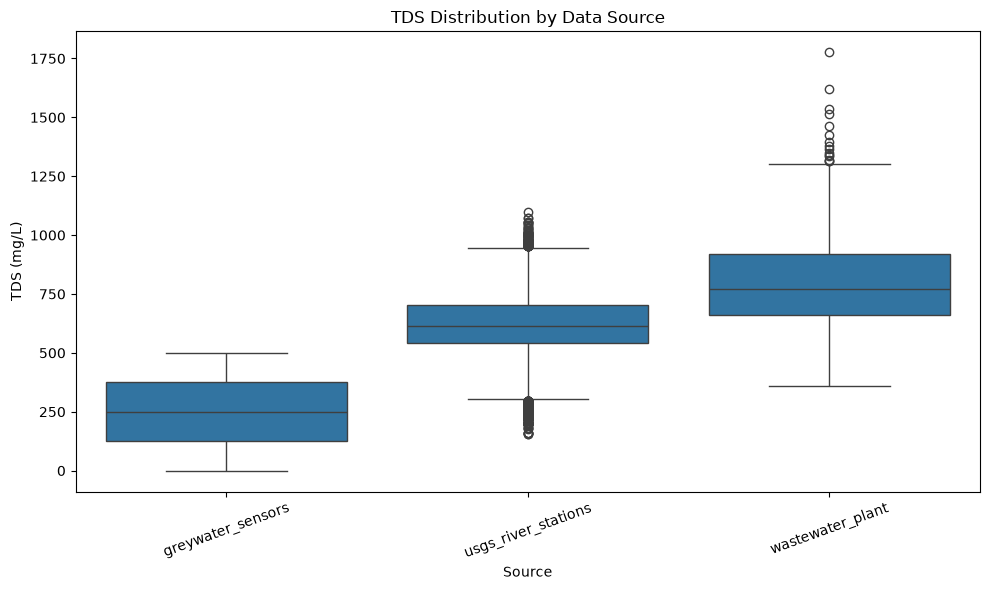

In [126]:
# ==========================================
# TDS DISTRIBUTION BY SOURCE
# ==========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cleaned_df,
    x="source",
    y="tds_mgl"
)

plt.title("TDS Distribution by Data Source")
plt.xlabel("Source")
plt.ylabel("TDS (mg/L)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [127]:
# ==========================================
# FILTER STATUS — BALANCED RANDOM FOREST
# ==========================================

balanced_filter_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_filter_model.fit(
    X_train,
    y_filter_train
)

print("Balanced Filter Status model trained successfully.")

Balanced Filter Status model trained successfully.


In [128]:
# ==========================================
# BALANCED FILTER STATUS — VALIDATION
# ==========================================

y_filter_balanced_pred = balanced_filter_model.predict(X_val)

accuracy_balanced = accuracy_score(
    y_filter_val,
    y_filter_balanced_pred
)

balanced_acc_balanced = balanced_accuracy_score(
    y_filter_val,
    y_filter_balanced_pred
)

macro_f1_balanced = f1_score(
    y_filter_val,
    y_filter_balanced_pred,
    average="macro"
)

print("=" * 60)
print("BALANCED FILTER STATUS — VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy_balanced:.4f}")
print(f"Balanced Accuracy: {balanced_acc_balanced:.4f}")
print(f"Macro F1-score:    {macro_f1_balanced:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_balanced_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        y_filter_balanced_pred
    )
)

BALANCED FILTER STATUS — VALIDATION RESULTS
Accuracy:          0.8333
Balanced Accuracy: 0.7402
Macro F1-score:    0.7373

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.87      0.80      0.84      2970
      Normal       0.69      0.80      0.74      1807
        Good       0.41      0.41      0.41       200

    accuracy                           0.83      6940
   macro avg       0.74      0.74      0.74      6940
weighted avg       0.84      0.83      0.84      6940

Confusion Matrix:
[[1869   93    0    1]
 [  47 2389  529    5]
 [   0  252 1444  111]
 [   0    0  119   81]]


In [129]:
# ==========================================
# FILTER STATUS — HISTOGRAM GRADIENT BOOSTING
# ==========================================

from sklearn.ensemble import HistGradientBoostingClassifier

hgb_filter_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

hgb_filter_model.fit(
    X_train,
    y_filter_train
)

print("Histogram Gradient Boosting model trained successfully.")

Histogram Gradient Boosting model trained successfully.


In [130]:
# ==========================================
# HISTOGRAM GRADIENT BOOSTING — VALIDATION
# ==========================================

y_filter_hgb_pred = hgb_filter_model.predict(X_val)

accuracy_hgb = accuracy_score(
    y_filter_val,
    y_filter_hgb_pred
)

balanced_acc_hgb = balanced_accuracy_score(
    y_filter_val,
    y_filter_hgb_pred
)

macro_f1_hgb = f1_score(
    y_filter_val,
    y_filter_hgb_pred,
    average="macro"
)

print("=" * 60)
print("HISTOGRAM GRADIENT BOOSTING — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_hgb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_hgb:.4f}")
print(f"Macro F1-score:    {macro_f1_hgb:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_hgb_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        y_filter_hgb_pred
    )
)

HISTOGRAM GRADIENT BOOSTING — VALIDATION
Accuracy:          0.8402
Balanced Accuracy: 0.6962
Macro F1-score:    0.7096

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.85      0.85      0.85      2970
      Normal       0.72      0.78      0.74      1807
        Good       0.43      0.21      0.28       200

    accuracy                           0.84      6940
   macro avg       0.74      0.70      0.71      6940
weighted avg       0.84      0.84      0.84      6940

Confusion Matrix:
[[1860  102    1    0]
 [  41 2524  401    4]
 [   2  348 1405   52]
 [   0    0  158   42]]


In [131]:
# ==========================================
# TDS vs FILTER STATUS
# ==========================================

tds_filter = (
    cleaned_df
    .groupby(
        pd.qcut(
            cleaned_df["tds_mgl"],
            q=10,
            duplicates="drop"
        )
    )["filter_status_code"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

tds_filter = tds_filter.reindex(
    columns=[0, 1, 2, 3],
    fill_value=0
)

tds_filter.columns = [
    "Replace",
    "Degraded",
    "Normal",
    "Good"
]

print("=" * 70)
print("FILTER STATUS DISTRIBUTION ACROSS TDS DECILES")
print("=" * 70)

print((tds_filter * 100).round(2))

FILTER STATUS DISTRIBUTION ACROSS TDS DECILES
                    Replace  Degraded  Normal   Good
tds_mgl                                             
(0.005, 117.515]       0.41     27.86   58.42  13.31
(117.515, 232.61]      2.94     35.92   53.97   7.18
(232.61, 337.093]     13.88     40.67   41.82   3.63
(337.093, 422.632]    32.04     38.00   28.82   1.14
(422.632, 493.191]    46.87     32.89   19.46   0.77
(493.191, 563.75]     94.39      3.05    2.35   0.20
(563.75, 606.086]     67.54     31.86    0.45   0.14
(606.086, 669.589]    17.32     81.81    0.54   0.33
(669.589, 747.204]     3.38     95.17    1.05   0.39
(747.204, 1776.5]      0.34     42.69   55.27   1.70


In [132]:
# ==========================================
# SENSOR SKEWNESS ANALYSIS
# ==========================================

skewness = X_train.skew().sort_values(ascending=False)

print("=" * 60)
print("SENSOR SKEWNESS")
print("=" * 60)

print(skewness.round(3))

SENSOR SKEWNESS
turbidity_ntu    9.097
photodiode_mv    1.446
tds_mgl         -0.202
flow_lpm        -0.329
ph              -1.289
dtype: float64


In [133]:
# ==========================================
# CREATE TRANSFORMED SENSOR FEATURES
# ==========================================

X_train_eng = X_train.copy()
X_val_eng = X_val.copy()

# Log transformations for highly skewed sensors
X_train_eng["turbidity_log"] = np.log1p(X_train_eng["turbidity_ntu"])
X_val_eng["turbidity_log"] = np.log1p(X_val_eng["turbidity_ntu"])

X_train_eng["photodiode_log"] = np.log1p(X_train_eng["photodiode_mv"])
X_val_eng["photodiode_log"] = np.log1p(X_val_eng["photodiode_mv"])

print("Engineered feature sets created.")

print("\nOriginal features:", X_train.shape[1])
print("Engineered features:", X_train_eng.shape[1])

print("\nNew features:")
print("  ✓ turbidity_log")
print("  ✓ photodiode_log")

Engineered feature sets created.

Original features: 5
Engineered features: 7

New features:
  ✓ turbidity_log
  ✓ photodiode_log


In [134]:
# ==========================================
# FILTER STATUS — ENGINEERED FEATURES
# ==========================================

engineered_filter_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

engineered_filter_model.fit(
    X_train_eng,
    y_filter_train
)

# Validation prediction
y_filter_eng_pred = engineered_filter_model.predict(X_val_eng)

# Metrics
accuracy_eng = accuracy_score(
    y_filter_val,
    y_filter_eng_pred
)

balanced_acc_eng = balanced_accuracy_score(
    y_filter_val,
    y_filter_eng_pred
)

macro_f1_eng = f1_score(
    y_filter_val,
    y_filter_eng_pred,
    average="macro"
)

print("=" * 60)
print("ENGINEERED FILTER STATUS — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_eng:.4f}")
print(f"Balanced Accuracy: {balanced_acc_eng:.4f}")
print(f"Macro F1-score:    {macro_f1_eng:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_eng_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        y_filter_eng_pred
    )
)

ENGINEERED FILTER STATUS — VALIDATION
Accuracy:          0.8307
Balanced Accuracy: 0.7374
Macro F1-score:    0.7354

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.87      0.80      0.83      2970
      Normal       0.68      0.80      0.74      1807
        Good       0.41      0.40      0.41       200

    accuracy                           0.83      6940
   macro avg       0.74      0.74      0.74      6940
weighted avg       0.84      0.83      0.83      6940

Confusion Matrix:
[[1868   94    0    1]
 [  47 2373  546    4]
 [   0  255 1444  108]
 [   0    0  120   80]]


In [135]:
# ==========================================
# INSPECT FILTER STATUS PROBABILITIES
# ==========================================

# Get predicted probabilities from the balanced model
filter_probabilities = balanced_filter_model.predict_proba(X_val)

# Probability of the Good class (code 3)
good_probabilities = filter_probabilities[:, 3]

print("=" * 60)
print("GOOD CLASS PROBABILITY DISTRIBUTION")
print("=" * 60)

print(f"Minimum:  {good_probabilities.min():.4f}")
print(f"25%:      {np.percentile(good_probabilities, 25):.4f}")
print(f"Median:   {np.median(good_probabilities):.4f}")
print(f"75%:      {np.percentile(good_probabilities, 75):.4f}")
print(f"Maximum:  {good_probabilities.max():.4f}")

print("\nActual Good samples:")
print(f"Count: {sum(y_filter_val == 3)}")

print("\nGood probability for actual Good samples:")
print(
    pd.Series(
        good_probabilities[y_filter_val.to_numpy() == 3]
    ).describe().round(4)
)

GOOD CLASS PROBABILITY DISTRIBUTION
Minimum:  0.0000
25%:      0.0000
Median:   0.0000
75%:      0.0000
Maximum:  0.9867

Actual Good samples:
Count: 200

Good probability for actual Good samples:
count    200.0000
mean       0.4194
std        0.2349
min        0.0000
25%        0.2533
50%        0.4383
75%        0.5883
max        0.9867
dtype: float64


In [138]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Test different probability thresholds for the Good class
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

results = []

for threshold in thresholds:

    # Get normal model predictions
    threshold_pred = balanced_filter_model.predict(X_val).copy()

    # Force prediction to Good when Good probability reaches threshold
    good_mask = good_probabilities >= threshold
    threshold_pred[good_mask] = 3

    # Convert to binary: Good vs Not Good
    y_true_good = (y_filter_val == 3).astype(int)
    y_pred_good = (threshold_pred == 3).astype(int)

    good_precision = precision_score(
        y_true_good,
        y_pred_good,
        zero_division=0
    )

    good_recall = recall_score(
        y_true_good,
        y_pred_good,
        zero_division=0
    )

    good_f1 = f1_score(
        y_true_good,
        y_pred_good,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Good Precision": good_precision,
        "Good Recall": good_recall,
        "Good F1": good_f1,
        "Predicted Good": sum(threshold_pred == 3)
    })

threshold_results = pd.DataFrame(results)

print("=" * 75)
print("GOOD CLASS — THRESHOLD ANALYSIS")
print("=" * 75)

print(
    threshold_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

GOOD CLASS — THRESHOLD ANALYSIS
 Threshold  Good Precision  Good Recall  Good F1  Predicted Good
     0.200           0.324        0.795    0.461             490
     0.250           0.346        0.755    0.475             436
     0.300           0.360        0.675    0.470             375
     0.350           0.373        0.600    0.460             322
     0.400           0.384        0.540    0.449             281
     0.450           0.409        0.485    0.444             237
     0.500           0.409        0.405    0.407             198
     0.550           0.409        0.405    0.407             198
     0.600           0.409        0.405    0.407             198
     0.650           0.409        0.405    0.407             198
     0.700           0.409        0.405    0.407             198


In [139]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Use the best Good threshold found so far
GOOD_THRESHOLD = 0.25

# Start with normal balanced RF predictions
threshold_025_pred = balanced_filter_model.predict(X_val).copy()

# Override with Good when probability reaches threshold
good_mask = good_probabilities >= GOOD_THRESHOLD
threshold_025_pred[good_mask] = 3

# Overall metrics
accuracy_025 = accuracy_score(y_filter_val, threshold_025_pred)
balanced_acc_025 = balanced_accuracy_score(y_filter_val, threshold_025_pred)
macro_f1_025 = f1_score(y_filter_val, threshold_025_pred, average="macro")

print("=" * 60)
print("FILTER STATUS — GOOD THRESHOLD = 0.25")
print("=" * 60)

print(f"Accuracy:          {accuracy_025:.4f}")
print(f"Balanced Accuracy: {balanced_acc_025:.4f}")
print(f"Macro F1-score:    {macro_f1_025:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        threshold_025_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_filter_val, threshold_025_pred))

FILTER STATUS — GOOD THRESHOLD = 0.25
Accuracy:          0.8212
Balanced Accuracy: 0.8063
Macro F1-score:    0.7452

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.87      0.80      0.84      2970
      Normal       0.70      0.71      0.70      1807
        Good       0.35      0.76      0.47       200

    accuracy                           0.82      6940
   macro avg       0.72      0.81      0.75      6940
weighted avg       0.84      0.82      0.83      6940


Confusion Matrix:
[[1869   93    0    1]
 [  47 2389  515   19]
 [   0  252 1290  265]
 [   0    0   49  151]]


In [141]:
# ==========================================
# FILTER STATUS — INTERACTION FEATURES
# ==========================================

X_train_int = X_train.copy()
X_val_int = X_val.copy()

# TDS / turbidity relationship
X_train_int["tds_turbidity_ratio"] = (
    X_train_int["tds_mgl"] / (X_train_int["turbidity_ntu"] + 1)
)

X_val_int["tds_turbidity_ratio"] = (
    X_val_int["tds_mgl"] / (X_val_int["turbidity_ntu"] + 1)
)

# Photodiode / turbidity relationship
X_train_int["photo_turbidity_ratio"] = (
    X_train_int["photodiode_mv"] / (X_train_int["turbidity_ntu"] + 1)
)

X_val_int["photo_turbidity_ratio"] = (
    X_val_int["photodiode_mv"] / (X_val_int["turbidity_ntu"] + 1)
)

# TDS × turbidity interaction
X_train_int["tds_turbidity_product"] = (
    X_train_int["tds_mgl"] * X_train_int["turbidity_ntu"]
)

X_val_int["tds_turbidity_product"] = (
    X_val_int["tds_mgl"] * X_val_int["turbidity_ntu"]
)

print("=" * 60)
print("INTERACTION FEATURES CREATED")
print("=" * 60)

print(f"Original features:    {X_train.shape[1]}")
print(f"Engineered features:  {X_train_int.shape[1]}")

print("\nNew features:")
print([
    "tds_turbidity_ratio",
    "photo_turbidity_ratio",
    "tds_turbidity_product"
])

INTERACTION FEATURES CREATED
Original features:    5
Engineered features:  8

New features:
['tds_turbidity_ratio', 'photo_turbidity_ratio', 'tds_turbidity_product']


In [142]:
# ==========================================
# FILTER STATUS — INTERACTION RF
# ==========================================

interaction_filter_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

interaction_filter_model.fit(
    X_train_int,
    y_filter_train
)

# Validation prediction
y_filter_int_pred = interaction_filter_model.predict(X_val_int)

# Metrics
accuracy_int = accuracy_score(
    y_filter_val,
    y_filter_int_pred
)

balanced_acc_int = balanced_accuracy_score(
    y_filter_val,
    y_filter_int_pred
)

macro_f1_int = f1_score(
    y_filter_val,
    y_filter_int_pred,
    average="macro"
)

print("=" * 60)
print("INTERACTION FILTER STATUS — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_int:.4f}")
print(f"Balanced Accuracy: {balanced_acc_int:.4f}")
print(f"Macro F1-score:    {macro_f1_int:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_int_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        y_filter_int_pred
    )
)

INTERACTION FILTER STATUS — VALIDATION
Accuracy:          0.8336
Balanced Accuracy: 0.7331
Macro F1-score:    0.7332

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.95      0.96      1963
    Degraded       0.88      0.80      0.84      2970
      Normal       0.69      0.81      0.74      1807
        Good       0.41      0.37      0.39       200

    accuracy                           0.83      6940
   macro avg       0.74      0.73      0.73      6940
weighted avg       0.84      0.83      0.84      6940


Confusion Matrix:
[[1866   96    0    1]
 [  42 2381  543    4]
 [   0  241 1464  102]
 [   0    0  126   74]]


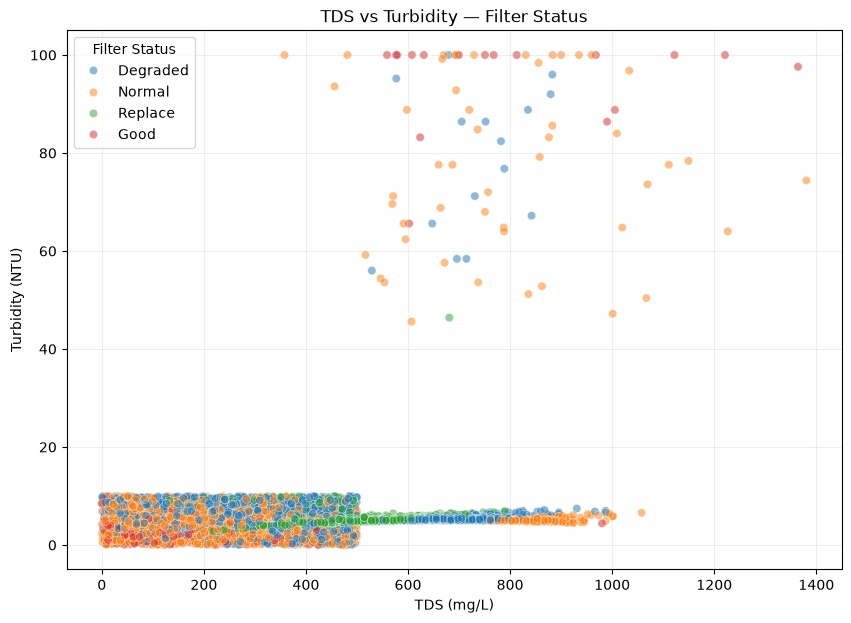

In [143]:
# ==========================================
# FILTER STATUS — SENSOR RELATIONSHIP
# ==========================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cleaned_df.sample(
        n=min(8000, len(cleaned_df)),
        random_state=42
    ),
    x="tds_mgl",
    y="turbidity_ntu",
    hue="filter_status",
    alpha=0.5
)

plt.title("TDS vs Turbidity — Filter Status")
plt.xlabel("TDS (mg/L)")
plt.ylabel("Turbidity (NTU)")
plt.legend(title="Filter Status")
plt.grid(alpha=0.2)
plt.show()


In [144]:
from sklearn.ensemble import ExtraTreesClassifier

# ==========================================
# EXTRA TREES — FILTER STATUS
# ==========================================

extra_filter_model = ExtraTreesClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

extra_filter_model.fit(
    X_train,
    y_filter_train
)

# Validation prediction
y_filter_extra_pred = extra_filter_model.predict(X_val)

# Metrics
accuracy_extra = accuracy_score(
    y_filter_val,
    y_filter_extra_pred
)

balanced_acc_extra = balanced_accuracy_score(
    y_filter_val,
    y_filter_extra_pred
)

macro_f1_extra = f1_score(
    y_filter_val,
    y_filter_extra_pred,
    average="macro"
)

print("=" * 60)
print("EXTRA TREES — FILTER STATUS VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_extra:.4f}")
print(f"Balanced Accuracy: {balanced_acc_extra:.4f}")
print(f"Macro F1-score:    {macro_f1_extra:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        y_filter_extra_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        y_filter_extra_pred
    )
)

EXTRA TREES — FILTER STATUS VALIDATION
Accuracy:          0.8331
Balanced Accuracy: 0.6981
Macro F1-score:    0.7150

Classification Report:
              precision    recall  f1-score   support

     Replace       0.98      0.94      0.96      1963
    Degraded       0.83      0.85      0.84      2970
      Normal       0.71      0.76      0.73      1807
        Good       0.49      0.24      0.33       200

    accuracy                           0.83      6940
   macro avg       0.75      0.70      0.71      6940
weighted avg       0.83      0.83      0.83      6940


Confusion Matrix:
[[1853  109    0    1]
 [  40 2510  418    2]
 [   0  390 1370   47]
 [   0    1  150   49]]


In [145]:
# ==========================================
# CHECK DATA SEQUENCE STRUCTURE
# ==========================================

print("=" * 60)
print("SEQUENCE / SAMPLE ID ANALYSIS")
print("=" * 60)

print("\nSample ID data type:")
print(cleaned_df["sample_id"].dtype)

print("\nFirst 10 sample IDs:")
print(cleaned_df["sample_id"].head(10).to_list())

print("\nLast 10 sample IDs:")
print(cleaned_df["sample_id"].tail(10).to_list())

print("\nUnique sample IDs:")
print(cleaned_df["sample_id"].nunique())

print("\nRows:")
print(len(cleaned_df))

print("\nSample ID duplicated:")
print(cleaned_df["sample_id"].duplicated().sum())

print("\nSample ID monotonic increasing:")
print(cleaned_df["sample_id"].is_monotonic_increasing)

SEQUENCE / SAMPLE ID ANALYSIS

Sample ID data type:
int64

First 10 sample IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Last 10 sample IDs:
[46258, 46259, 46260, 46261, 46262, 46263, 46264, 46265, 46266, 46267]

Unique sample IDs:
46268

Rows:
46268

Sample ID duplicated:
0

Sample ID monotonic increasing:
True


In [146]:
# ==========================================
# CHECK SEQUENCE ORGANIZATION BY SOURCE
# ==========================================

sequence_df = cleaned_df.sort_values("sample_id").reset_index(drop=True)

# Find where the source changes
source_changes = (
    sequence_df["source"] != sequence_df["source"].shift()
).sum()

print("=" * 60)
print("SEQUENCE ORGANIZATION")
print("=" * 60)

print(f"Total source changes: {source_changes}")

print("\nSource at the beginning of the sequence:")
print(sequence_df[["sample_id", "source"]].head(10).to_string(index=False))

print("\nSource at the end of the sequence:")
print(sequence_df[["sample_id", "source"]].tail(10).to_string(index=False))

print("\nFirst and last sample ID for each source:")

source_ranges = (
    sequence_df
    .groupby("source")["sample_id"]
    .agg(["min", "max", "count"])
    .sort_values("min")
)

print(source_ranges)

SEQUENCE ORGANIZATION
Total source changes: 23141

Source at the beginning of the sequence:
 sample_id              source
         0   greywater_sensors
         1   greywater_sensors
         2 usgs_river_stations
         3 usgs_river_stations
         4 usgs_river_stations
         5   greywater_sensors
         6 usgs_river_stations
         7   greywater_sensors
         8   greywater_sensors
         9 usgs_river_stations

Source at the end of the sequence:
 sample_id              source
     46258 usgs_river_stations
     46259 usgs_river_stations
     46260 usgs_river_stations
     46261   greywater_sensors
     46262   greywater_sensors
     46263   greywater_sensors
     46264 usgs_river_stations
     46265 usgs_river_stations
     46266   greywater_sensors
     46267   greywater_sensors

First and last sample ID for each source:
                     min    max  count
source                                
greywater_sensors      0  46267  19656
usgs_river_stations    2  4626

In [147]:
# ==========================================
# ORDINAL FILTER STATUS TARGETS
# ==========================================

# Filter status codes:
# 0 = Replace
# 1 = Degraded
# 2 = Normal
# 3 = Good

# Binary ordinal targets
# Threshold 1: 1 if status >= Degraded
y_filter_ge_1_train = (y_filter_train >= 1).astype(int)
y_filter_ge_1_val = (y_filter_val >= 1).astype(int)

# Threshold 2: 1 if status >= Normal
y_filter_ge_2_train = (y_filter_train >= 2).astype(int)
y_filter_ge_2_val = (y_filter_val >= 2).astype(int)

# Threshold 3: 1 if status >= Good
y_filter_ge_3_train = (y_filter_train >= 3).astype(int)
y_filter_ge_3_val = (y_filter_val >= 3).astype(int)

print("=" * 60)
print("ORDINAL FILTER TARGETS")
print("=" * 60)

print("\nThreshold 1: Degraded or better")
print("Train:", y_filter_ge_1_train.value_counts().sort_index().to_dict())
print("Val:  ", y_filter_ge_1_val.value_counts().sort_index().to_dict())

print("\nThreshold 2: Normal or better")
print("Train:", y_filter_ge_2_train.value_counts().sort_index().to_dict())
print("Val:  ", y_filter_ge_2_val.value_counts().sort_index().to_dict())

print("\nThreshold 3: Good")
print("Train:", y_filter_ge_3_train.value_counts().sort_index().to_dict())
print("Val:  ", y_filter_ge_3_val.value_counts().sort_index().to_dict())

ORDINAL FILTER TARGETS

Threshold 1: Degraded or better
Train: {0: 9159, 1: 23228}
Val:   {0: 1963, 1: 4977}

Threshold 2: Normal or better
Train: {0: 23018, 1: 9369}
Val:   {0: 4933, 1: 2007}

Threshold 3: Good
Train: {0: 31455, 1: 932}
Val:   {0: 6740, 1: 200}


In [148]:
# ==========================================
# ORDINAL RANDOM FOREST MODELS
# ==========================================

# Model 1: Degraded or better vs Replace
ordinal_model_1 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Model 2: Normal or better vs Degraded/Replace
ordinal_model_2 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Model 3: Good vs everything below Good
ordinal_model_3 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
ordinal_model_1.fit(
    X_train,
    y_filter_ge_1_train
)

ordinal_model_2.fit(
    X_train,
    y_filter_ge_2_train
)

ordinal_model_3.fit(
    X_train,
    y_filter_ge_3_train
)

print("=" * 60)
print("ORDINAL MODELS TRAINED")
print("=" * 60)

print("Model 1: Replace vs Degraded+")
print("Model 2: Below Normal vs Normal+")
print("Model 3: Below Good vs Good")

print("\nAll three models trained successfully.")

ORDINAL MODELS TRAINED
Model 1: Replace vs Degraded+
Model 2: Below Normal vs Normal+
Model 3: Below Good vs Good

All three models trained successfully.


In [149]:
# ==========================================
# EVALUATE ORDINAL MODEL BOUNDARIES
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

ordinal_models = [
    ("Threshold 1 — Degraded or Better", ordinal_model_1,
     y_filter_ge_1_val),
    
    ("Threshold 2 — Normal or Better", ordinal_model_2,
     y_filter_ge_2_val),
    
    ("Threshold 3 — Good", ordinal_model_3,
     y_filter_ge_3_val)
]

for name, model, y_true in ordinal_models:

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1-score:          {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["No", "Yes"],
            digits=2
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


Threshold 1 — Degraded or Better
Accuracy:          0.9790
Balanced Accuracy: 0.9727
F1-score:          0.9854

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.96      0.96      1963
         Yes       0.98      0.99      0.99      4977

    accuracy                           0.98      6940
   macro avg       0.98      0.97      0.97      6940
weighted avg       0.98      0.98      0.98      6940

Confusion Matrix:
[[1881   82]
 [  64 4913]]

Threshold 2 — Normal or Better
Accuracy:          0.8830
Balanced Accuracy: 0.8855
F1-score:          0.8150

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.88      0.91      4933
         Yes       0.75      0.89      0.82      2007

    accuracy                           0.88      6940
   macro avg       0.85      0.89      0.86      6940
weighted avg       0.89      0.88      0.89      6940

Confusion Matrix:
[[4339  594]


In [150]:
# ==========================================
# ORDINAL PROBABILITIES
# ==========================================

# Probability of the positive class for each ordinal boundary
p_ge_1 = ordinal_model_1.predict_proba(X_val)[:, 1]
p_ge_2 = ordinal_model_2.predict_proba(X_val)[:, 1]
p_ge_3 = ordinal_model_3.predict_proba(X_val)[:, 1]

print("=" * 70)
print("ORDINAL MODEL PROBABILITY SUMMARY")
print("=" * 70)

probability_data = pd.DataFrame({
    "P(>=Degraded)": p_ge_1,
    "P(>=Normal)": p_ge_2,
    "P(>=Good)": p_ge_3,
    "Actual Status": y_filter_val.values
})

print("\nProbability statistics:")
print(
    probability_data[
        ["P(>=Degraded)", "P(>=Normal)", "P(>=Good)"]
    ].describe().round(3)
)

print("\nMean probabilities by actual filter status:")
print(
    probability_data
    .groupby("Actual Status")[
        ["P(>=Degraded)", "P(>=Normal)", "P(>=Good)"]
    ]
    .mean()
    .round(3)
)

print("\nStatus mapping:")
print("0 = Replace")
print("1 = Degraded")
print("2 = Normal")
print("3 = Good")

ORDINAL MODEL PROBABILITY SUMMARY

Probability statistics:
       P(>=Degraded)  P(>=Normal)  P(>=Good)
count       6940.000     6940.000   6940.000
mean           0.710        0.321      0.046
std            0.433        0.389      0.147
min            0.000        0.000      0.000
25%            0.037        0.000      0.000
50%            0.997        0.013      0.000
75%            1.000        0.707      0.000
max            1.000        1.000      1.000

Mean probabilities by actual filter status:
               P(>=Degraded)  P(>=Normal)  P(>=Good)
Actual Status                                       
0                      0.048        0.006      0.000
1                      0.956        0.202      0.006
2                      0.993        0.788      0.110
3                      0.997        0.959      0.498

Status mapping:
0 = Replace
1 = Degraded
2 = Normal
3 = Good


In [151]:
# ==========================================
# CHECK ORDINAL PROBABILITY CONSISTENCY
# ==========================================

# Check whether probabilities follow:
# P(>=Degraded) >= P(>=Normal) >= P(>=Good)

violation_1 = p_ge_2 > p_ge_1
violation_2 = p_ge_3 > p_ge_2

total_violations = violation_1 | violation_2

print("=" * 60)
print("ORDINAL PROBABILITY CONSISTENCY")
print("=" * 60)

print(
    f"P(>=Normal) > P(>=Degraded): "
    f"{violation_1.sum()} samples "
    f"({violation_1.mean() * 100:.2f}%)"
)

print(
    f"P(>=Good) > P(>=Normal): "
    f"{violation_2.sum()} samples "
    f"({violation_2.mean() * 100:.2f}%)"
)

print(
    f"\nTotal samples with any violation: "
    f"{total_violations.sum()} "
    f"({total_violations.mean() * 100:.2f}%)"
)

ORDINAL PROBABILITY CONSISTENCY
P(>=Normal) > P(>=Degraded): 141 samples (2.03%)
P(>=Good) > P(>=Normal): 25 samples (0.36%)

Total samples with any violation: 166 (2.39%)


In [152]:
# ==========================================
# ORDINAL 4-CLASS FILTER PREDICTION
# ==========================================

# Decision thresholds
DEGRADED_THRESHOLD = 0.50
NORMAL_THRESHOLD = 0.50
GOOD_THRESHOLD = 0.25

# Start with Replace
ordinal_filter_pred = np.zeros(len(X_val), dtype=int)

# Degraded:
# >= Degraded but < Normal
degraded_mask = (
    (p_ge_1 >= DEGRADED_THRESHOLD) &
    (p_ge_2 < NORMAL_THRESHOLD)
)

ordinal_filter_pred[degraded_mask] = 1

# Normal:
# >= Normal but < Good
normal_mask = (
    (p_ge_2 >= NORMAL_THRESHOLD) &
    (p_ge_3 < GOOD_THRESHOLD)
)

ordinal_filter_pred[normal_mask] = 2

# Good:
# >= Good threshold
good_mask_ordinal = p_ge_3 >= GOOD_THRESHOLD

ordinal_filter_pred[good_mask_ordinal] = 3

# ==========================================
# EVALUATION
# ==========================================

ordinal_accuracy = accuracy_score(
    y_filter_val,
    ordinal_filter_pred
)

ordinal_balanced_acc = balanced_accuracy_score(
    y_filter_val,
    ordinal_filter_pred
)

ordinal_macro_f1 = f1_score(
    y_filter_val,
    ordinal_filter_pred,
    average="macro"
)

print("=" * 65)
print("ORDINAL 4-CLASS FILTER STATUS — VALIDATION")
print("=" * 65)

print(f"Accuracy:          {ordinal_accuracy:.4f}")
print(f"Balanced Accuracy: {ordinal_balanced_acc:.4f}")
print(f"Macro F1-score:    {ordinal_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_val,
        ordinal_filter_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_filter_val,
        ordinal_filter_pred
    )
)

print("\nPredicted class distribution:")
print(
    pd.Series(ordinal_filter_pred)
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Replace",
        1: "Degraded",
        2: "Normal",
        3: "Good"
    })
)

ORDINAL 4-CLASS FILTER STATUS — VALIDATION
Accuracy:          0.8098
Balanced Accuracy: 0.8141
Macro F1-score:    0.7347

Classification Report:
              precision    recall  f1-score   support

     Replace       0.97      0.96      0.96      1963
    Degraded       0.89      0.78      0.83      2970
      Normal       0.67      0.70      0.69      1807
        Good       0.32      0.82      0.46       200

    accuracy                           0.81      6940
   macro avg       0.71      0.81      0.73      6940
weighted avg       0.84      0.81      0.82      6940


Confusion Matrix:
[[1881   81    0    1]
 [  63 2309  576   22]
 [   0  216 1266  325]
 [   0    0   36  164]]

Predicted class distribution:
Replace     1944
Degraded    2606
Normal      1878
Good         512
Name: count, dtype: int64


In [153]:
# ==========================================
# ORDINAL GOOD THRESHOLD SEARCH
# ==========================================

good_thresholds = [
    0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60,
    0.65, 0.70
]

threshold_results = []

for good_threshold in good_thresholds:

    # Start with Replace
    pred = np.zeros(len(X_val), dtype=int)

    # Degraded
    degraded_mask = (
        (p_ge_1 >= 0.50) &
        (p_ge_2 < 0.50)
    )
    pred[degraded_mask] = 1

    # Normal
    normal_mask = (
        (p_ge_2 >= 0.50) &
        (p_ge_3 < good_threshold)
    )
    pred[normal_mask] = 2

    # Good
    good_mask = p_ge_3 >= good_threshold
    pred[good_mask] = 3

    accuracy = accuracy_score(y_filter_val, pred)
    balanced_acc = balanced_accuracy_score(y_filter_val, pred)
    macro_f1 = f1_score(y_filter_val, pred, average="macro")

    # Good recall
    good_recall = recall_score(
        (y_filter_val == 3).astype(int),
        (pred == 3).astype(int),
        zero_division=0
    )

    threshold_results.append({
        "Good Threshold": good_threshold,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro F1": macro_f1,
        "Good Recall": good_recall,
        "Predicted Good": np.sum(pred == 3)
    })

ordinal_threshold_results = pd.DataFrame(threshold_results)

print("=" * 80)
print("ORDINAL FILTER — GOOD THRESHOLD SEARCH")
print("=" * 80)

print(
    ordinal_threshold_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nBest by Balanced Accuracy:")
print(
    ordinal_threshold_results.loc[
        ordinal_threshold_results["Balanced Accuracy"].idxmax()
    ].to_string()
)

print("\nBest by Macro F1:")
print(
    ordinal_threshold_results.loc[
        ordinal_threshold_results["Macro F1"].idxmax()
    ].to_string()
)

ORDINAL FILTER — GOOD THRESHOLD SEARCH
 Good Threshold  Accuracy  Balanced Accuracy  Macro F1  Good Recall  Predicted Good
         0.2500    0.8098             0.8141    0.7347       0.8200             512
         0.3000    0.8130             0.8060    0.7372       0.7700             467
         0.3500    0.8174             0.8047    0.7441       0.7450             423
         0.4000    0.8202             0.7951    0.7454       0.6900             380
         0.4500    0.8223             0.7794    0.7432       0.6100             330
         0.5000    0.8269             0.7683    0.7467       0.5400             267
         0.5500    0.8291             0.7548    0.7436       0.4700             224
         0.6000    0.8304             0.7371    0.7357       0.3850             178
         0.6500    0.8318             0.7230    0.7284       0.3150             137
         0.7000    0.8326             0.7081    0.7166       0.2450             103

Best by Balanced Accuracy:
Good Thre

In [154]:
# ==========================================
# FINAL FILTER MODEL — TEST EVALUATION
# ==========================================

# Get ordinal probabilities on the untouched test set
p_test_ge_1 = ordinal_model_1.predict_proba(X_test)[:, 1]
p_test_ge_2 = ordinal_model_2.predict_proba(X_test)[:, 1]
p_test_ge_3 = ordinal_model_3.predict_proba(X_test)[:, 1]

# Locked thresholds
DEGRADED_THRESHOLD = 0.50
NORMAL_THRESHOLD = 0.50
GOOD_THRESHOLD = 0.50

# Start with Replace
filter_test_pred = np.zeros(len(X_test), dtype=int)

# Degraded
degraded_mask = (
    (p_test_ge_1 >= DEGRADED_THRESHOLD) &
    (p_test_ge_2 < NORMAL_THRESHOLD)
)
filter_test_pred[degraded_mask] = 1

# Normal
normal_mask = (
    (p_test_ge_2 >= NORMAL_THRESHOLD) &
    (p_test_ge_3 < GOOD_THRESHOLD)
)
filter_test_pred[normal_mask] = 2

# Good
good_mask = p_test_ge_3 >= GOOD_THRESHOLD
filter_test_pred[good_mask] = 3

# ==========================================
# TEST METRICS
# ==========================================

test_accuracy = accuracy_score(
    y_filter_test,
    filter_test_pred
)

test_balanced_acc = balanced_accuracy_score(
    y_filter_test,
    filter_test_pred
)

test_macro_f1 = f1_score(
    y_filter_test,
    filter_test_pred,
    average="macro"
)

print("=" * 70)
print("FINAL FILTER STATUS — TEST SET")
print("=" * 70)

print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Balanced Accuracy: {test_balanced_acc:.4f}")
print(f"Macro F1-score:    {test_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_filter_test,
        filter_test_pred,
        target_names=["Replace", "Degraded", "Normal", "Good"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_filter_test,
        filter_test_pred
    )
)

print("\nPredicted class distribution:")
print(
    pd.Series(filter_test_pred)
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Replace",
        1: "Degraded",
        2: "Normal",
        3: "Good"
    })
)

FINAL FILTER STATUS — TEST SET
Accuracy:          0.8203
Balanced Accuracy: 0.7611
Macro F1-score:    0.7344

Classification Report:
              precision    recall  f1-score   support

     Replace       0.96      0.97      0.96      1963
    Degraded       0.89      0.77      0.82      2970
      Normal       0.67      0.77      0.72      1809
        Good       0.36      0.53      0.43       199

    accuracy                           0.82      6941
   macro avg       0.72      0.76      0.73      6941
weighted avg       0.84      0.82      0.83      6941


Confusion Matrix:
[[1899   63    1    0]
 [  74 2291  599    6]
 [   0  230 1398  181]
 [   0    0   93  106]]

Predicted class distribution:
Replace     1973
Degraded    2584
Normal      2091
Good         293
Name: count, dtype: int64


In [155]:
# ==========================================
# FINAL WATER HEALTH — TEST EVALUATION
# ==========================================

# Predict on untouched test set
y_health_test_pred = water_model.predict(X_test)

# Metrics
health_test_accuracy = accuracy_score(
    y_health_test,
    y_health_test_pred
)

health_test_balanced_acc = balanced_accuracy_score(
    y_health_test,
    y_health_test_pred
)

health_test_macro_f1 = f1_score(
    y_health_test,
    y_health_test_pred,
    average="macro"
)

print("=" * 70)
print("FINAL WATER HEALTH — TEST SET")
print("=" * 70)

print(f"Accuracy:          {health_test_accuracy:.4f}")
print(f"Balanced Accuracy: {health_test_balanced_acc:.4f}")
print(f"Macro F1-score:    {health_test_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_health_test,
        y_health_test_pred,
        target_names=["Unsafe", "Moderate", "Safe"],
        digits=2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_health_test,
        y_health_test_pred
    )
)

FINAL WATER HEALTH — TEST SET
Accuracy:          0.9999
Balanced Accuracy: 0.9998
Macro F1-score:    0.9998

Classification Report:
              precision    recall  f1-score   support

      Unsafe       1.00      1.00      1.00      2768
    Moderate       1.00      1.00      1.00      2431
        Safe       1.00      1.00      1.00      1742

    accuracy                           1.00      6941
   macro avg       1.00      1.00      1.00      6941
weighted avg       1.00      1.00      1.00      6941


Confusion Matrix:
[[2768    0    0]
 [   0 2431    0]
 [   0    1 1741]]


In [156]:
# ==========================================
# CREATE MODEL DIRECTORY
# ==========================================

import os

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 60)
print("MODEL DIRECTORY")
print("=" * 60)

print(f"Directory: {MODEL_DIR}")
print("Created/verified successfully.")

MODEL DIRECTORY
Directory: models
Created/verified successfully.


In [157]:
# ==========================================
# SAVE FINAL AEGIS H2O MODELS
# ==========================================

import joblib

# Save Water Health model
water_model_path = os.path.join(
    MODEL_DIR,
    "water_health_model.pkl"
)

joblib.dump(
    water_model,
    water_model_path
)

# Save ordinal Filter Status models
filter_model_1_path = os.path.join(
    MODEL_DIR,
    "filter_status_ordinal_1.pkl"
)

filter_model_2_path = os.path.join(
    MODEL_DIR,
    "filter_status_ordinal_2.pkl"
)

filter_model_3_path = os.path.join(
    MODEL_DIR,
    "filter_status_ordinal_3.pkl"
)

joblib.dump(
    ordinal_model_1,
    filter_model_1_path
)

joblib.dump(
    ordinal_model_2,
    filter_model_2_path
)

joblib.dump(
    ordinal_model_3,
    filter_model_3_path
)

print("=" * 60)
print("FINAL MODELS SAVED")
print("=" * 60)

print(f"Water Health:  {water_model_path}")
print(f"Filter Model 1: {filter_model_1_path}")
print(f"Filter Model 2: {filter_model_2_path}")
print(f"Filter Model 3: {filter_model_3_path}")

FINAL MODELS SAVED
Water Health:  models\water_health_model.pkl
Filter Model 1: models\filter_status_ordinal_1.pkl
Filter Model 2: models\filter_status_ordinal_2.pkl
Filter Model 3: models\filter_status_ordinal_3.pkl


In [158]:
# ==========================================
# VERIFY SAVED MODELS
# ==========================================

import joblib
import numpy as np

# Load models from disk
loaded_water_model = joblib.load(
    "models/water_health_model.pkl"
)

loaded_filter_model_1 = joblib.load(
    "models/filter_status_ordinal_1.pkl"
)

loaded_filter_model_2 = joblib.load(
    "models/filter_status_ordinal_2.pkl"
)

loaded_filter_model_3 = joblib.load(
    "models/filter_status_ordinal_3.pkl"
)

# ==========================================
# WATER HEALTH VERIFICATION
# ==========================================

original_water_pred = water_model.predict(X_val)
loaded_water_pred = loaded_water_model.predict(X_val)

water_predictions_match = np.array_equal(
    original_water_pred,
    loaded_water_pred
)

# ==========================================
# FILTER MODEL VERIFICATION
# ==========================================

original_f1 = ordinal_model_1.predict(X_val)
loaded_f1 = loaded_filter_model_1.predict(X_val)

original_f2 = ordinal_model_2.predict(X_val)
loaded_f2 = loaded_filter_model_2.predict(X_val)

original_f3 = ordinal_model_3.predict(X_val)
loaded_f3 = loaded_filter_model_3.predict(X_val)

filter_predictions_match = (
    np.array_equal(original_f1, loaded_f1)
    and
    np.array_equal(original_f2, loaded_f2)
    and
    np.array_equal(original_f3, loaded_f3)
)

# ==========================================
# RESULT
# ==========================================

print("=" * 60)
print("MODEL SAVE / LOAD VERIFICATION")
print("=" * 60)

print(f"Water Health predictions match: {water_predictions_match}")
print(f"Filter predictions match:       {filter_predictions_match}")

if water_predictions_match and filter_predictions_match:
    print("\n✓ All saved models verified successfully.")
    print("✓ Saved models produce identical predictions.")
else:
    print("\n⚠ Verification failed. Check the saved model files.")

MODEL SAVE / LOAD VERIFICATION
Water Health predictions match: True
Filter predictions match:       True

✓ All saved models verified successfully.
✓ Saved models produce identical predictions.


In [159]:
# ==========================================
# AEGIS H2O PREDICTION FUNCTION
# ==========================================

def predict_aegis_h2o(
    ph,
    tds_mgl,
    flow_lpm,
    turbidity_ntu,
    photodiode_mv
):
    """
    Predict Water Health and Filter Status
    using the five live Aegis H2O sensor inputs.
    """

    # Create input DataFrame
    sensor_input = pd.DataFrame([{
        "ph": ph,
        "tds_mgl": tds_mgl,
        "flow_lpm": flow_lpm,
        "turbidity_ntu": turbidity_ntu,
        "photodiode_mv": photodiode_mv
    }])

    # ==========================================
    # WATER HEALTH
    # ==========================================

    health_prediction = loaded_water_model.predict(
        sensor_input
    )[0]

    health_labels = {
        0: "Unsafe",
        1: "Moderate",
        2: "Safe"
    }

    water_health = health_labels[health_prediction]

    # ==========================================
    # FILTER STATUS — ORDINAL MODELS
    # ==========================================

    p_ge_degraded = loaded_filter_model_1.predict_proba(
        sensor_input
    )[0, 1]

    p_ge_normal = loaded_filter_model_2.predict_proba(
        sensor_input
    )[0, 1]

    p_ge_good = loaded_filter_model_3.predict_proba(
        sensor_input
    )[0, 1]

    # Final thresholds
    if p_ge_degraded < 0.50:
        filter_status_code = 0

    elif p_ge_normal < 0.50:
        filter_status_code = 1

    elif p_ge_good < 0.50:
        filter_status_code = 2

    else:
        filter_status_code = 3

    filter_labels = {
        0: "Replace",
        1: "Degraded",
        2: "Normal",
        3: "Good"
    }

    filter_status = filter_labels[filter_status_code]

    # ==========================================
    # RETURN RESULTS
    # ==========================================

    return {
        "water_health": water_health,
        "filter_status": filter_status,
        "filter_probabilities": {
            "p_ge_degraded": round(float(p_ge_degraded), 4),
            "p_ge_normal": round(float(p_ge_normal), 4),
            "p_ge_good": round(float(p_ge_good), 4)
        }
    }


print("=" * 60)
print("AEGIS H2O PREDICTION FUNCTION CREATED")
print("=" * 60)
print("Function: predict_aegis_h2o()")
print("Inputs: 5 live sensor values")
print("Outputs: Water Health + Filter Status")

AEGIS H2O PREDICTION FUNCTION CREATED
Function: predict_aegis_h2o()
Inputs: 5 live sensor values
Outputs: Water Health + Filter Status


In [160]:
# ==========================================
# TEST AEGIS H2O PREDICTION
# ==========================================

test_result = predict_aegis_h2o(
    ph=7.5,
    tds_mgl=300,
    flow_lpm=450,
    turbidity_ntu=4.5,
    photodiode_mv=1200
)

print("=" * 60)
print("AEGIS H2O TEST PREDICTION")
print("=" * 60)

print(f"Water Health : {test_result['water_health']}")
print(f"Filter Status: {test_result['filter_status']}")

print("\nFilter probabilities:")
for name, probability in test_result["filter_probabilities"].items():
    print(f"{name}: {probability:.4f}")

AEGIS H2O TEST PREDICTION
Water Health : Moderate
Filter Status: Replace

Filter probabilities:
p_ge_degraded: 0.2533
p_ge_normal: 0.0500
p_ge_good: 0.0100


In [161]:
# ==========================================
# AEGIS H2O — SCENARIO TESTING
# ==========================================

scenarios = {
    "Likely Safe": {
        "ph": 7.5,
        "tds_mgl": 150,
        "flow_lpm": 100,
        "turbidity_ntu": 2.0,
        "photodiode_mv": 2200
    },

    "Moderate Condition": {
        "ph": 7.5,
        "tds_mgl": 450,
        "flow_lpm": 300,
        "turbidity_ntu": 5.0,
        "photodiode_mv": 1200
    },

    "Poor / Contaminated": {
        "ph": 6.5,
        "tds_mgl": 800,
        "flow_lpm": 500,
        "turbidity_ntu": 50,
        "photodiode_mv": 200
    }
}

for scenario_name, sensors in scenarios.items():

    result = predict_aegis_h2o(**sensors)

    print("\n" + "=" * 60)
    print(scenario_name)
    print("=" * 60)

    print(
        f"pH:             {sensors['ph']}"
    )
    print(
        f"TDS:            {sensors['tds_mgl']} mg/L"
    )
    print(
        f"Flow:           {sensors['flow_lpm']} L/min"
    )
    print(
        f"Turbidity:      {sensors['turbidity_ntu']} NTU"
    )
    print(
        f"Photodiode:     {sensors['photodiode_mv']} mV"
    )

    print("\nPrediction:")
    print(
        f"Water Health:   {result['water_health']}"
    )
    print(
        f"Filter Status:  {result['filter_status']}"
    )


Likely Safe
pH:             7.5
TDS:            150 mg/L
Flow:           100 L/min
Turbidity:      2.0 NTU
Photodiode:     2200 mV

Prediction:
Water Health:   Safe
Filter Status:  Normal

Moderate Condition
pH:             7.5
TDS:            450 mg/L
Flow:           300 L/min
Turbidity:      5.0 NTU
Photodiode:     1200 mV

Prediction:
Water Health:   Moderate
Filter Status:  Replace

Poor / Contaminated
pH:             6.5
TDS:            800 mg/L
Flow:           500 L/min
Turbidity:      50 NTU
Photodiode:     200 mV

Prediction:
Water Health:   Unsafe
Filter Status:  Degraded


In [162]:
# ==========================================
# ORDINAL FILTER MODEL — FEATURE IMPORTANCE
# ==========================================

feature_importance_df = pd.DataFrame({
    "Feature": sensor_features,

    ">= Degraded": ordinal_model_1.feature_importances_,

    ">= Normal": ordinal_model_2.feature_importances_,

    ">= Good": ordinal_model_3.feature_importances_
})

print("=" * 75)
print("ORDINAL FILTER MODEL — FEATURE IMPORTANCE")
print("=" * 75)

print(
    feature_importance_df
    .sort_values(">= Degraded", ascending=False)
    .to_string(index=False)
)

print("\n" + "=" * 75)
print("AVERAGE IMPORTANCE ACROSS ORDINAL MODELS")
print("=" * 75)

feature_importance_df["Average"] = feature_importance_df[
    [">= Degraded", ">= Normal", ">= Good"]
].mean(axis=1)

print(
    feature_importance_df
    .sort_values("Average", ascending=False)
    .to_string(index=False)
)

ORDINAL FILTER MODEL — FEATURE IMPORTANCE
      Feature  >= Degraded  >= Normal  >= Good
      tds_mgl     0.463104   0.380056 0.208962
     flow_lpm     0.248697   0.262011 0.214285
turbidity_ntu     0.124492   0.136688 0.213930
photodiode_mv     0.087025   0.123235 0.241963
           ph     0.076682   0.098010 0.120860

AVERAGE IMPORTANCE ACROSS ORDINAL MODELS
      Feature  >= Degraded  >= Normal  >= Good  Average
      tds_mgl     0.463104   0.380056 0.208962 0.350707
     flow_lpm     0.248697   0.262011 0.214285 0.241664
turbidity_ntu     0.124492   0.136688 0.213930 0.158370
photodiode_mv     0.087025   0.123235 0.241963 0.150741
           ph     0.076682   0.098010 0.120860 0.098517
